In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import rcParams
from pathlib import Path

rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amssymb}',
    'pgf.texsystem': 'pdflatex',
    'pgf.preamble': '',
    "font.family": "serif",
    "font.serif": ["times"],
    "axes.unicode_minus": False
})
plt.rc('xtick', top=True, bottom=True, labelsize=30, direction='in')
plt.rc('ytick', left=True, right=True, labelsize=30, direction='in')
plt.rc('xtick.major', size=16, pad=12, width=2.5)
plt.rc('ytick.major', size=16, pad=12, width=2.5)
plt.rc('xtick.minor', size=8, width=1.5)
plt.rc('ytick.minor', size=8, width=1.5)
plt.rc('axes', titlesize=35, labelsize=30, titleweight='bold', titlepad=20, linewidth=1, edgecolor='k')
plt.rc('figure', titlesize=35)
plt.rc('legend', fontsize=20, title_fontsize=30, frameon=True, framealpha=1)

In [2]:
df = pd.read_csv('../benchmark/benchmark.csv')

# ADD VIRTUAL ROWS FOR V6 higher params
v6k0 = df.query('(version in ["V6", "V0"]) & (test == "k0")')[
    ['date', 'seed', 'version', 'device', 'exetime', 'power']].rename(
    columns={'exetime': 'exetime_one', 'power': 'power_one'})
v8k0 = df.query('(version == "V8") & (test == "k0") & (val != 1)')
merged = v8k0.merge(v6k0, on=['date', 'seed', 'device'], how='right').rename(columns={'version_y': 'version'})
merged['exetime'] = merged['exetime_one'] * merged['val']
merged['power'] = merged['power_one'] * merged['val']
merged.drop(columns=['exetime_one', 'power_one', 'version_x'], inplace=True)
# merged
df = pd.concat([df, merged])

df['power_inst'] = df['power'] / (df['exetime'] * 2)
df['power_energy'] = df['power'] * 0.5 / 3600
df['exetime'] /= 60

df = df.sort_values(['device', 'date', 'seed', 'val', 'version']).copy().reset_index(drop=True)
df

,date,seed,test,val,version,device,exetime,power,power_inst,power_energy
0,20111116,72,k0,1,V0,A100,15.651023,201492.864,107.284181,27.985120
1,20111116,72,k0,1,V8,A100,0.186767,4211.259,187.901867,0.584897
2,20111116,72,k0,2,V0,A100,31.302046,402985.728,107.284181,55.970240
3,20111116,72,k0,2,V8,A100,0.322197,7782.444,201.285978,1.080895
4,20111116,72,k0,4,V0,A100,62.604093,805971.456,107.284181,111.940480
...,...,...,...,...,...,...,...,...,...,...
8059,20180929,861,part,4096,V8,RTX 3090,0.077508,3148.876,338.555325,0.437344
8060,20180929,861,part,8192,V8,RTX 3090,0.134855,5609.753,346.652267,0.779132
8061,20180929,861,part,16384,V8,RTX 3090,0.260402,10702.601,342.503044,1.486472
8062,20180929,861,part,32768,V8,RTX 3090,0.514563,21156.359,342.626939,2.938383


In [3]:
df['date'].unique()

array([20111116, 20140917, 20150907, 20160827, 20170623, 20180929])

In [4]:
def set_axis_fine_grid(ax, axis='both'):
    ax.minorticks_on()
    ax.grid(which='major', linestyle='-', linewidth='0.5', color='grey', axis=axis)
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='darkgrey', axis=axis)


def make_pair_panel(shape=(1, 2), sharey=True, figsize=(18, 7.5)):
    fig, axs = plt.subplots(*shape, figsize=figsize, tight_layout=True, sharey=sharey)
    for ax in axs.flat:
        ax.set_xscale('log')
        ax.set_yscale('log')
        set_axis_fine_grid(ax)
    return fig, *axs.flatten()


def reorder_list(lst, order):
    assert len(lst) == len(order)
    return [lst[i] for i in order]


def make_figure_legend(fig, axs, title, map_handles=None, map_labels=None, reorder=None):
    ax1_handles, ax1_labels = axs[0].get_legend_handles_labels()
    for ax in axs[1:]:
        assert len(ax1_handles) == len(ax.get_legend_handles_labels()[0]) and len(ax1_labels) == len(
            ax.get_legend_handles_labels()[1])

    nrows = 2 if len(ax1_handles) > 6 else 1
    ncols = int(np.ceil(len(ax1_handles) / nrows))

    if map_handles is not None:
        ax1_handles = list(map(map_handles, ax1_handles))
    if map_labels is not None:
        ax1_labels = list(map(map_labels, ax1_labels))
    if reorder is not None:
        ax1_handles = reorder_list(ax1_handles, reorder)
        ax1_labels = reorder_list(ax1_labels, reorder)

    leg = fig.legend(
        handles=ax1_handles,
        labels=ax1_labels,
        title=title,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.21 if nrows > 1 else -0.16),
        ncol=ncols,
        handlelength=2,
        markerscale=2,
    )
    for line in leg.get_lines():
        line.set_linewidth(3)

    for ax in axs:
        ax.legend().remove()

    return leg


def format_int_to_date(date):
    date = str(date)
    return f'{date[:4]}-{date[4:6]}-{date[6:]}'


def format_int_to_cr(date):
    return str({
        20111116: 2117,
        20140917: 2155,
        20150907: 2168,
        20160827: 2181,
        20170623: 2192,
        20180929: 2209,
    }[int(date)])


# array([20111116, 20140917, 20150907, 20160827, 20170623, 20180929])

def save_plot(name):
    plt.savefig(Path().resolve().parent / 'data' / 'publications' / f'{name}.pdf', bbox_inches='tight', pad_inches=0.1)
    plt.savefig(Path().resolve().parent / 'data' / 'publications' / f'{name}.png', bbox_inches='tight', pad_inches=0.1)

In [5]:
def plot_scale_vs_time_per_gpu(version):
    df_ = df.query(f'(version == "{version}") & (~device.str.endswith(")")) & ~(device in ["A2000", "RTX 3060"])')
    fig, ax1, ax2 = make_pair_panel()

    sns.lineplot(
        data=df_.query('test == "part"'),
        x='val',
        y='exetime',
        hue='device',
        marker='o',
        errorbar=('pi', 50),
        ax=ax1,
    )
    ax1.set(xlabel=r'Number of \textit{quasi-particles}', ylabel='Runtime (min)')

    sns.lineplot(
        data=df_.query('test == "k0"'),
        x='val',
        y='exetime',
        hue='device',
        marker='o',
        errorbar=('pi', 50),
        ax=ax2,
    )
    ax2.set(xlabel=r'Number of \textit{dynamic} parameters', ylabel='Runtime (min)')

    make_figure_legend(fig, (ax1, ax2), 'GPU', reorder=[1, 2, 3, 0])

    return fig, ax1, ax2

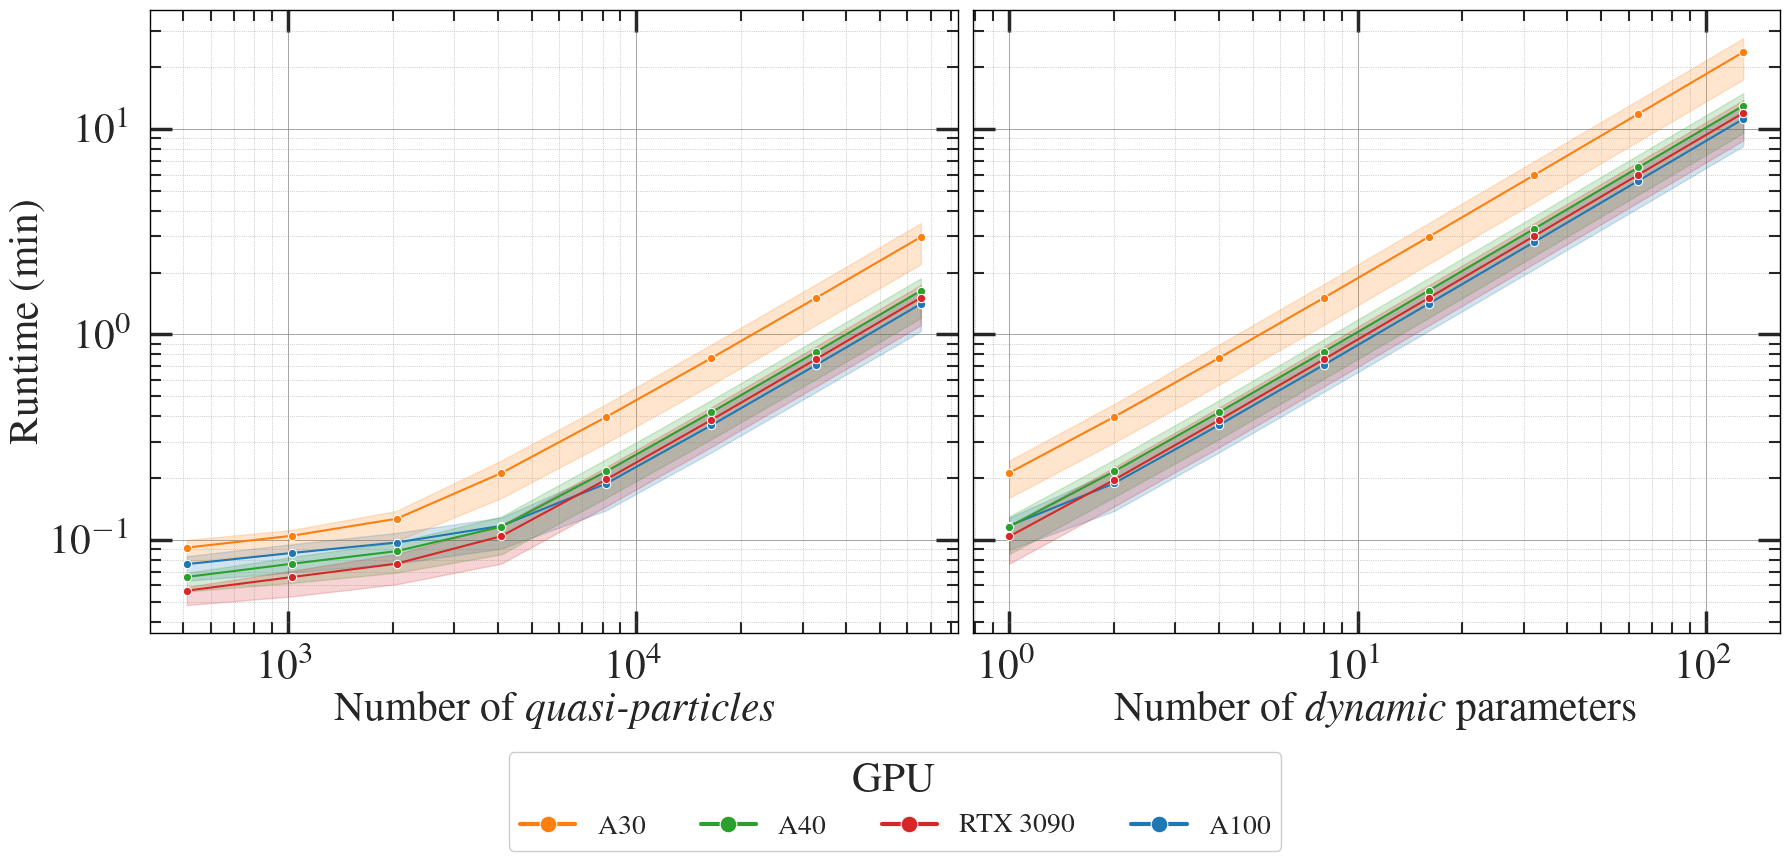

In [6]:
plot_scale_vs_time_per_gpu("V8")
save_plot(f'scale_vs_time_per_gpu')
plt.show()

In [7]:
def plot_scale_vs_time_per_gpu_date(version, date):
    df_ = df.query(f'(version == "{version}") & (date == {date})')
    fig, ax1, ax2 = make_pair_panel()

    sns.lineplot(
        data=df_.query('test == "part"'),
        x='val',
        y='exetime',
        hue='device',
        marker='o',
        errorbar=('pi', 95),
        ax=ax1,
    )
    ax1.set(xlabel=r'Number of \textit{quasi-particles}', ylabel='Runtime (min)')

    sns.lineplot(
        data=df_.query('test == "k0"'),
        x='val',
        y='exetime',
        hue='device',
        marker='o',
        errorbar=('pi', 95),
        ax=ax2,
    )
    ax2.set(xlabel=r'Number of \textit{dynamic} parameters', ylabel='Runtime (min)')

    make_figure_legend(fig, (ax1, ax2), 'GPU', reorder=[4, 7, 5, 6, 8, 0, 1, 2, 3])

    return fig, ax1, ax2

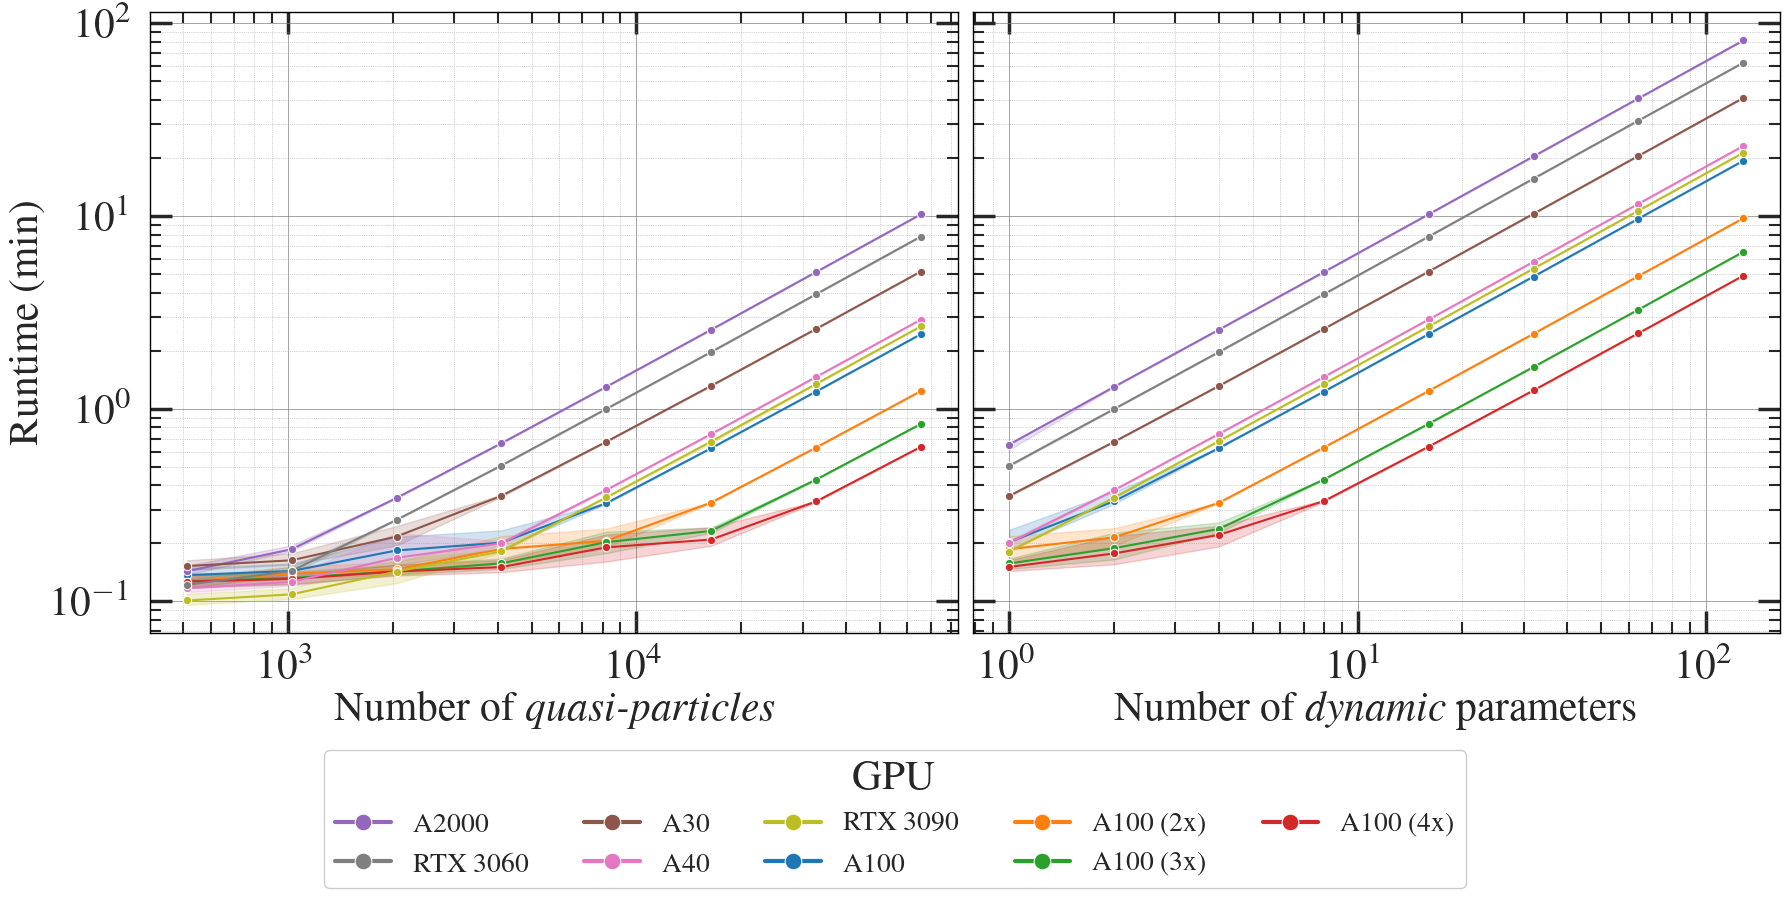

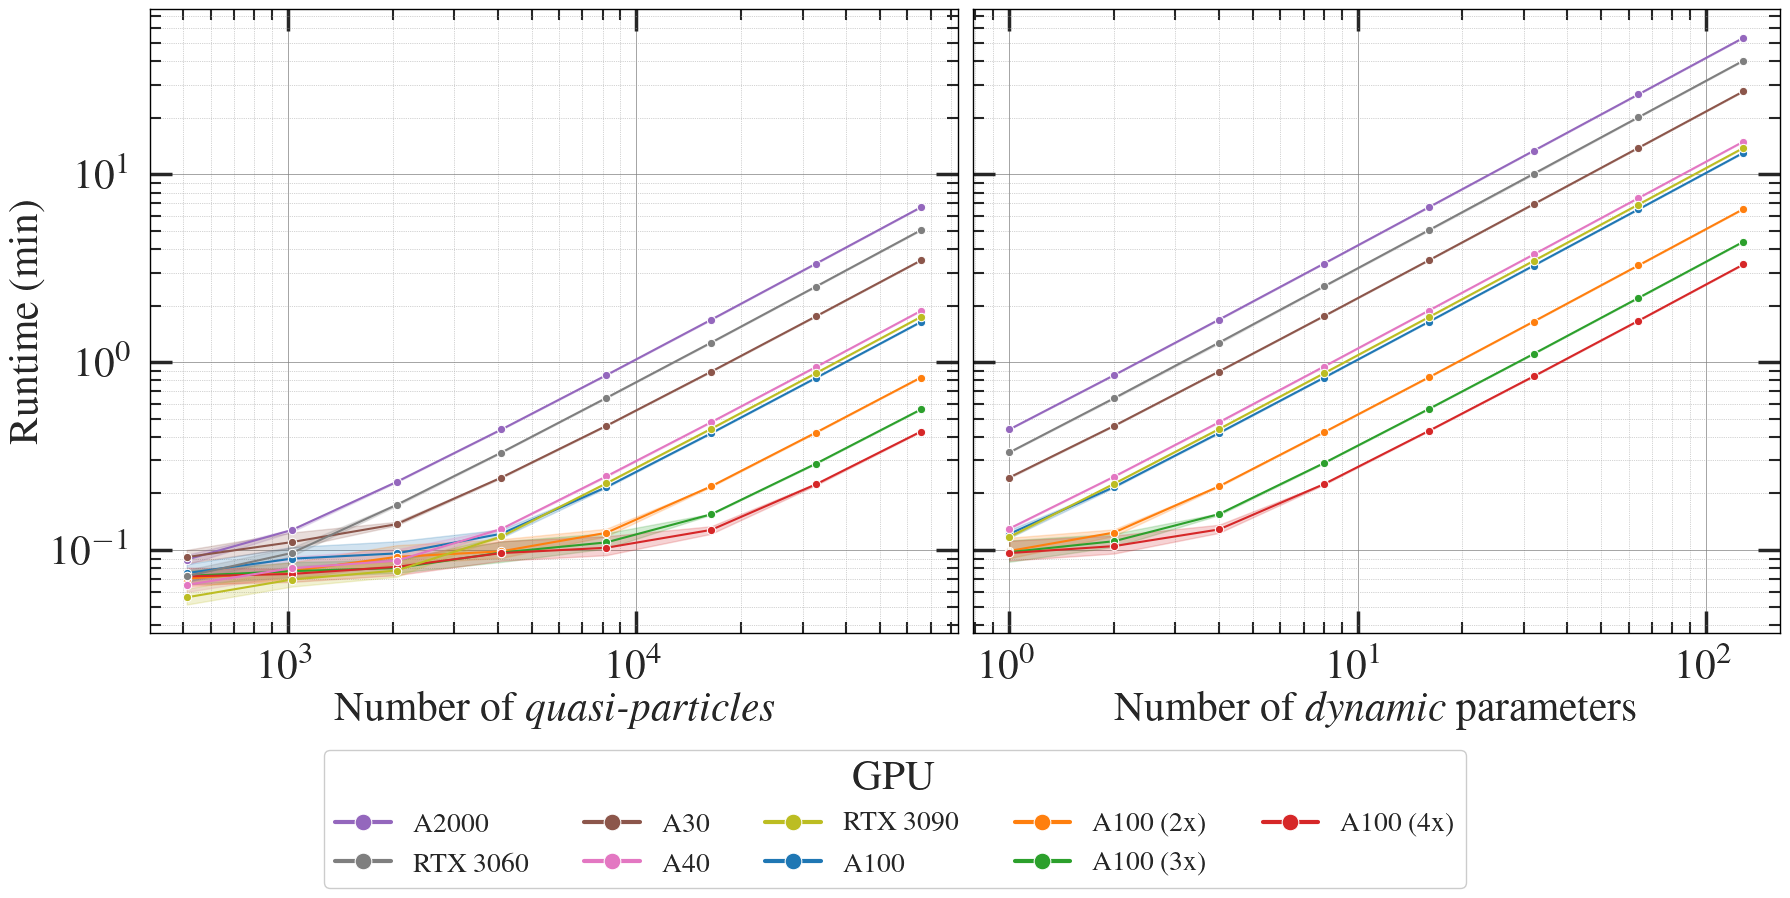

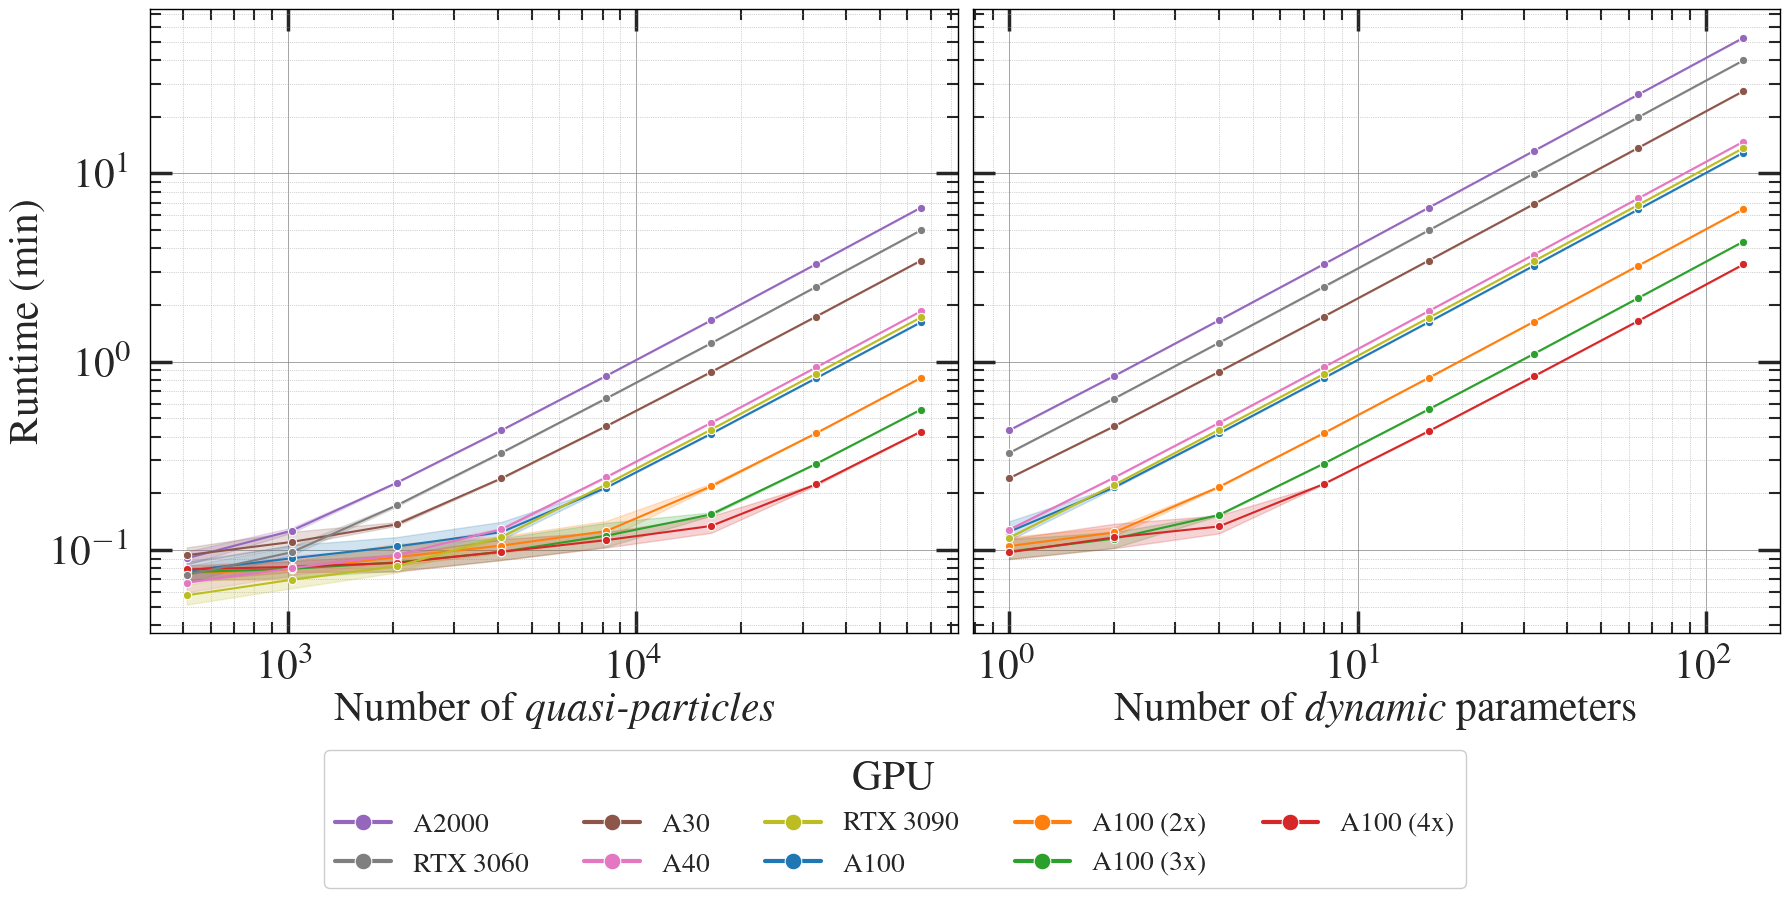

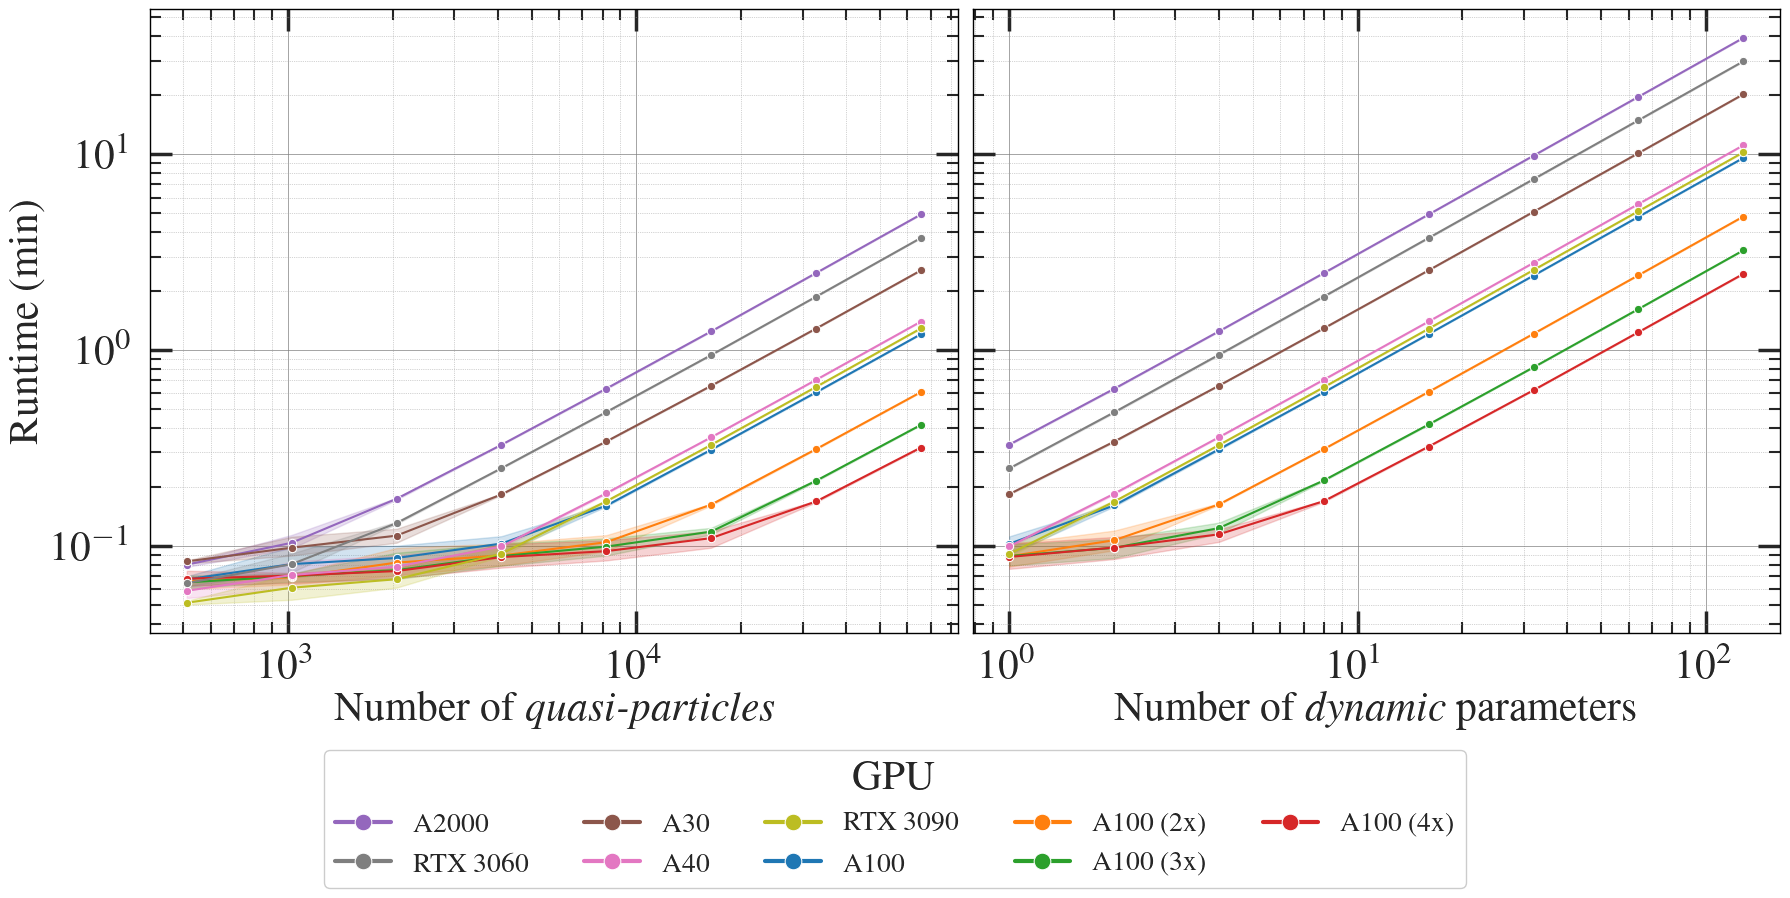

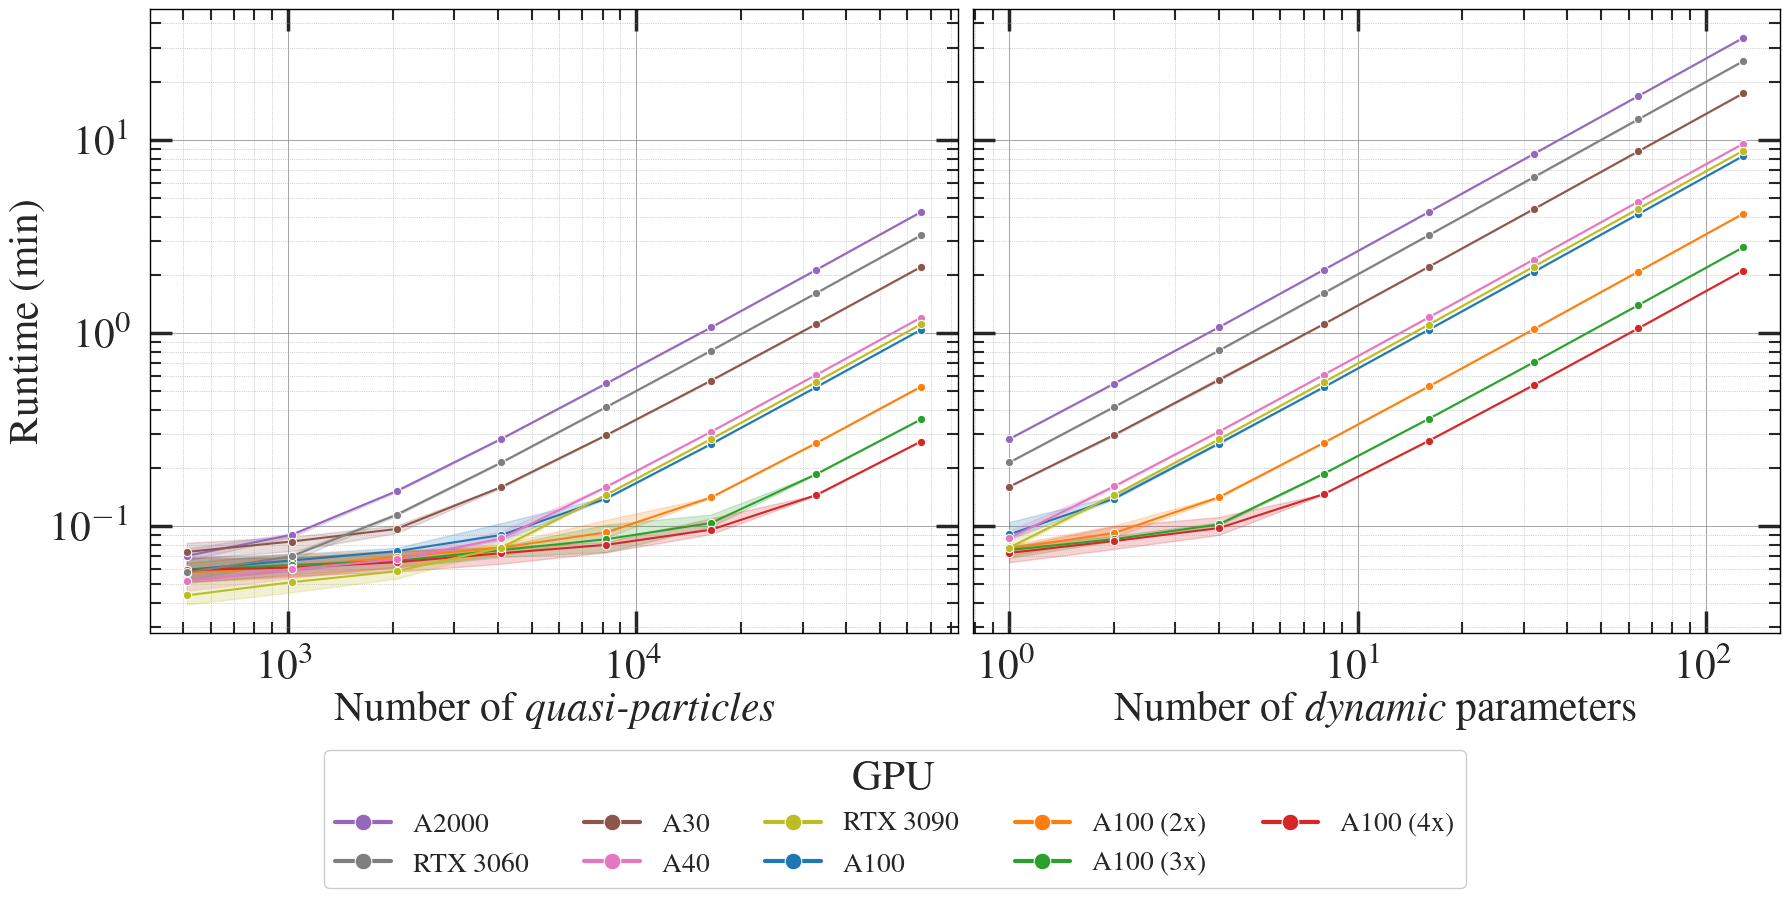

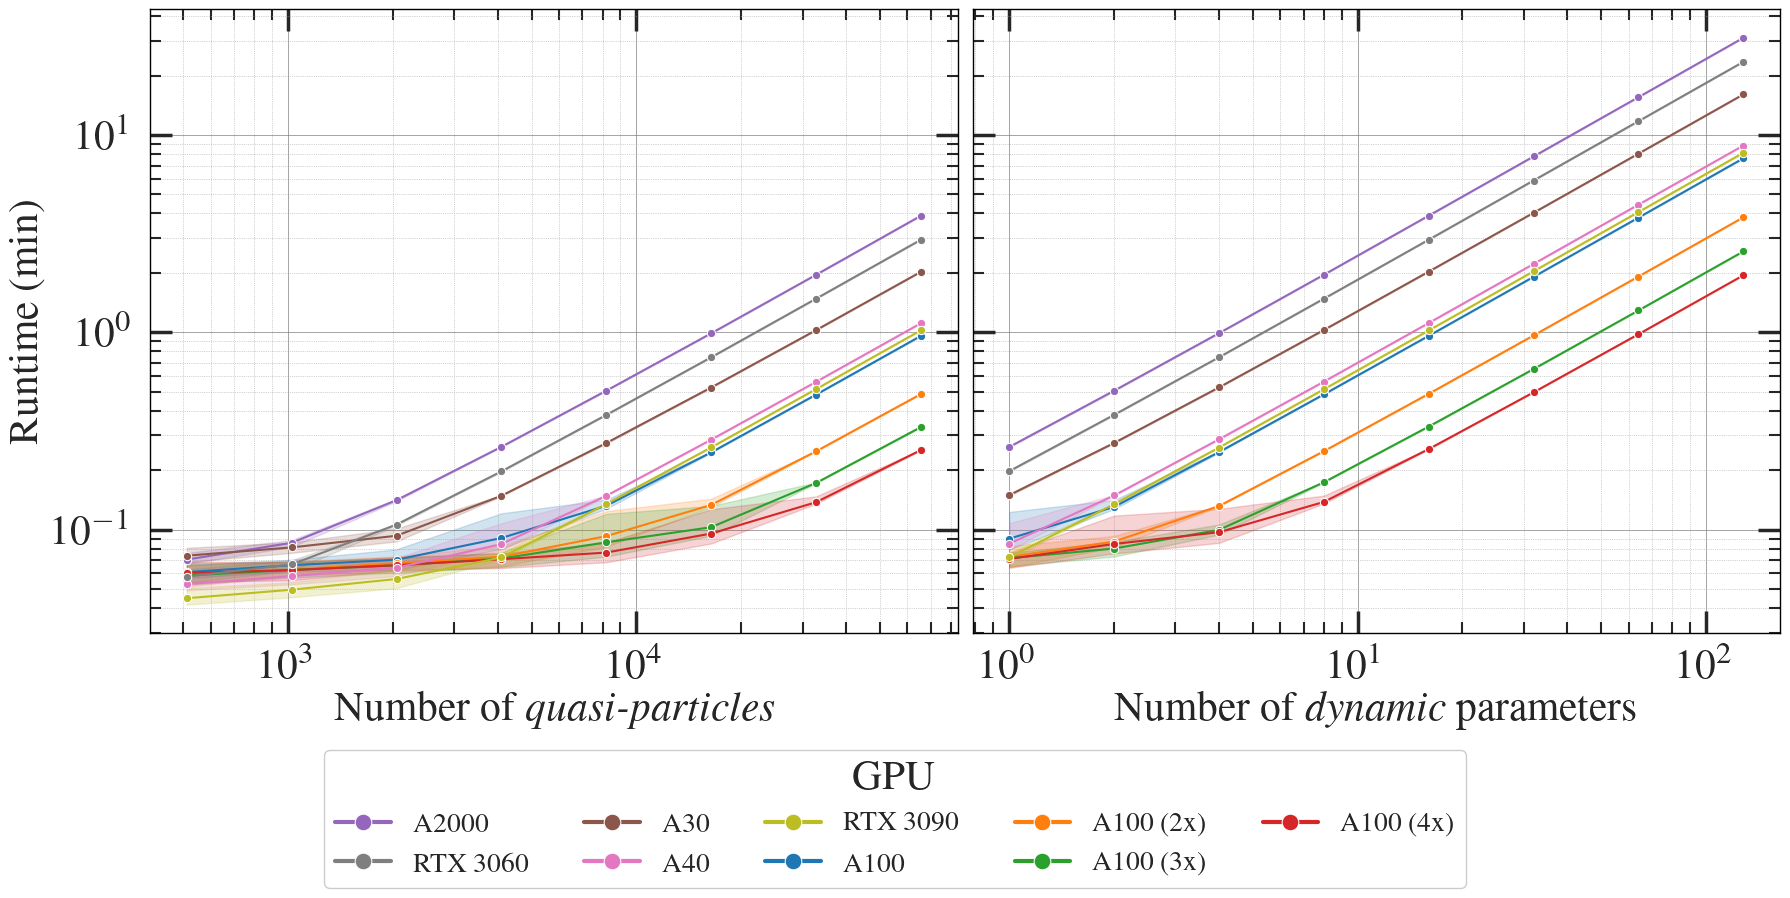

In [8]:
for date in df['date'].unique():
    plot_scale_vs_time_per_gpu_date("V8", date)
    save_plot(f'scale_vs_time_per_gpu_{date}')
    plt.show()

In [9]:
def plot_scale_vs_time_per_date_version(device, versions):
    def _make_legend(fig, axs):
        ax1_handles, ax1_labels = axs[0].get_legend_handles_labels()
        for ax in axs[1:]:
            assert len(ax1_handles) == len(ax.get_legend_handles_labels()[0]) and len(ax1_labels) == len(
                ax.get_legend_handles_labels()[1])

        leg1_handles = ax1_handles[len(ax1_handles) // 2:]
        leg1_labels = list(map(format_int_to_cr, ax1_labels[len(ax1_labels) // 2:]))

        leg2_handles = ax1_handles[len(ax1_handles) // 2 - 1: len(ax1_handles) // 2 + 1]
        leg2_labels = ['HelMod-4/CUDA', 'COSMICA (this work)']

        leg1 = fig.legend(
            handles=leg2_handles,
            labels=leg2_labels,
            title='Version',
            loc='lower center',
            ncol=8,
            bbox_to_anchor=(0.5, -0.145),
            handlelength=2,
            markerscale=2,
        )
        leg2 = fig.legend(
            handles=leg1_handles,
            labels=leg1_labels,
            title='Carrington Rotation',
            loc='lower center',
            ncol=8,
            bbox_to_anchor=(0.5, -0.075),
            handlelength=2,
            markerscale=2,
        )
        fig.add_artist(leg1)
        fig.add_artist(leg2)

        for line in leg1.get_lines() + leg2.get_lines():
            line.set_linewidth(3)
        for line in leg1.get_lines():
            line.set_color('k')

        for ax in axs:
            ax.legend().remove()

        return leg1, leg2

    fig, ax1, ax2, ax3, ax4 = make_pair_panel((2, 2), sharey='row', figsize=(18, 16))

    df_ = pd.merge(
        df.query(f'(device == "{device}") & (version == "{versions[0]}")'),
        df.query(f'(device == "{device}") & (version == "{versions[1]}")'),
        on=['date', 'seed', 'test', 'val', 'device'],
    )
    df_['ratio'] = df_['exetime_x'] / df_['exetime_y']

    sns.lineplot(
        data=df_.query('test == "part"'),
        x='val',
        y='ratio',
        hue='date',
        marker='o',
        errorbar=('pi', 95),
        palette='muted',
        ax=ax1,
    )
    ax1.set(title='(a)', yscale='linear', xlabel=r'Number of \textit{quasi-particles}', ylabel=r'Speedup ($\times$ times)')
    ax1.legend().remove()

    sns.lineplot(
        data=df_.query('test == "k0"'),
        x='val',
        y='ratio',
        hue='date',
        marker='o',
        errorbar=('pi', 95),
        palette='muted',
        ax=ax2,
    )
    ax2.set(title='(b)', yscale='linear', xlabel=r'Number of \textit{dynamic} parameters',
            ylabel=r'Speedup ($\times$ times)')
    ax2.legend().remove()

    df_ = df.query(f'(device == "{device}")')

    sns.lineplot(
        data=df_.query(f'(test == "part") & (version == "{versions[0]}")'),
        x='val',
        y='exetime',
        hue='date',
        marker='o',
        linestyle=':',
        errorbar=('pi', 95),
        palette='muted',
        ax=ax3,
    )
    sns.lineplot(
        data=df_.query(f'(test == "part") & (version == "{versions[1]}")'),
        x='val',
        y='exetime',
        hue='date',
        marker='o',
        linestyle='-',
        errorbar=('pi', 95),
        palette='muted',
        ax=ax3,
    )
    ax3.set(title='(c)', xlabel=r'Number of \textit{quasi-particles}', ylabel='Runtime (min)')

    sns.lineplot(
        data=df_.query(f'(test == "k0") & (version == "{versions[0]}")'),
        x='val',
        y='exetime',
        hue='date',
        marker='o',
        linestyle=':',
        errorbar=('pi', 95),
        palette='muted',
        ax=ax4,
    )
    sns.lineplot(
        data=df_.query(f'(test == "k0") & (version == "{versions[1]}")'),
        x='val',
        y='exetime',
        hue='date',
        marker='o',
        linestyle='-',
        errorbar=('pi', 95),
        palette='muted',
        ax=ax4,
    )
    ax4.set(title='(d)', xlabel=r'Number of \textit{dynamic} parameters', ylabel='Runtime (min)')

    _make_legend(fig, (ax3, ax4))

    fig.tight_layout(h_pad=2.5)

    return fig, ax1, ax2, ax3, ax4

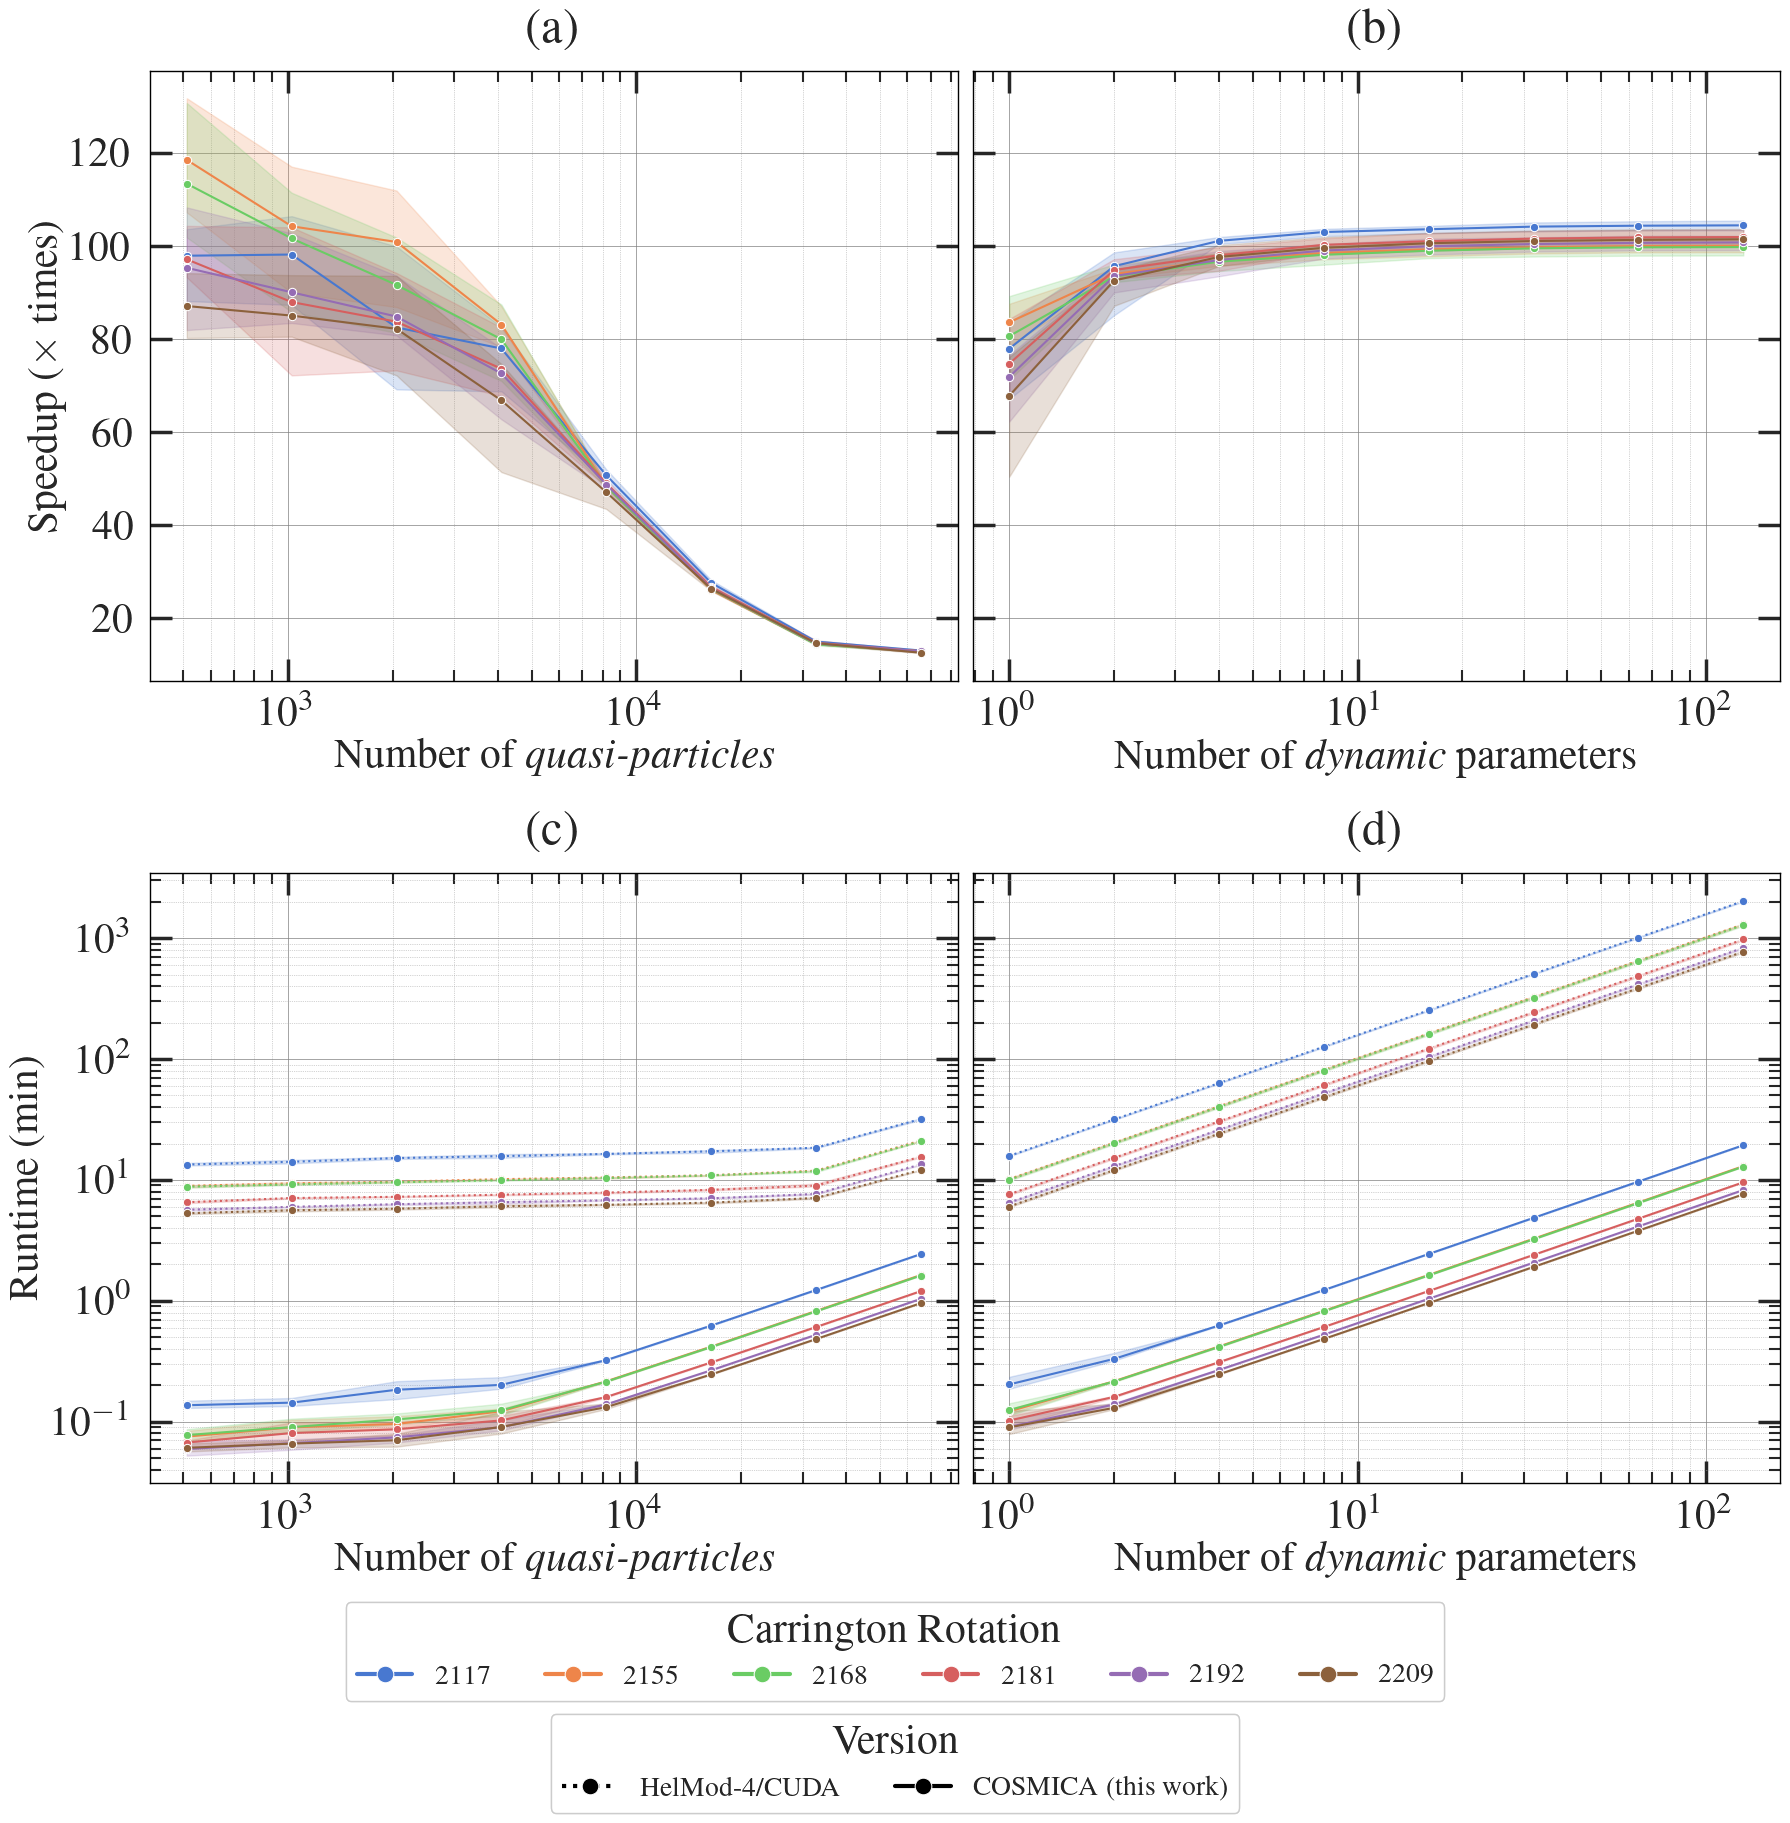

In [10]:
plot_scale_vs_time_per_date_version("A100", ("V0", "V8"))
save_plot('scale_vs_time_per_date_version')
plt.show()

In [11]:
def plot_scale_vs_speedup_per_date(device, versions):
    df_ = pd.merge(
        df.query(f'(device == "{device}") & (version == "{versions[0]}")'),
        df.query(f'(device == "{device}") & (version == "{versions[1]}")'),
        on=['date', 'seed', 'test', 'val', 'device'],
    )
    df_['ratio'] = df_['exetime_x'] / df_['exetime_y']
    fig, ax1, ax2 = make_pair_panel(sharey=True)

    sns.lineplot(
        data=df_.query('test == "part"'),
        x='val',
        y='ratio',
        hue='date',
        marker='o',
        errorbar=('pi', 95),
        palette='muted',
        ax=ax1,
    )
    ax1.set(yscale='linear', xlabel=r'Number of \textit{quasi-particles}', ylabel=r'Speedup ($\times$ times)')

    sns.lineplot(
        data=df_.query('test == "k0"'),
        x='val',
        y='ratio',
        hue='date',
        marker='o',
        errorbar=('pi', 95),
        palette='muted',
        ax=ax2,
    )
    ax2.set(yscale='linear', xlabel=r'Number of \textit{dynamic} parameters',
            ylabel=r'Speedup ($\times$ times)')

    leg = make_figure_legend(fig, (ax1, ax2), 'Carrington Rotation', map_labels=format_int_to_cr)
    leg.remove()

    return fig, ax1, ax2

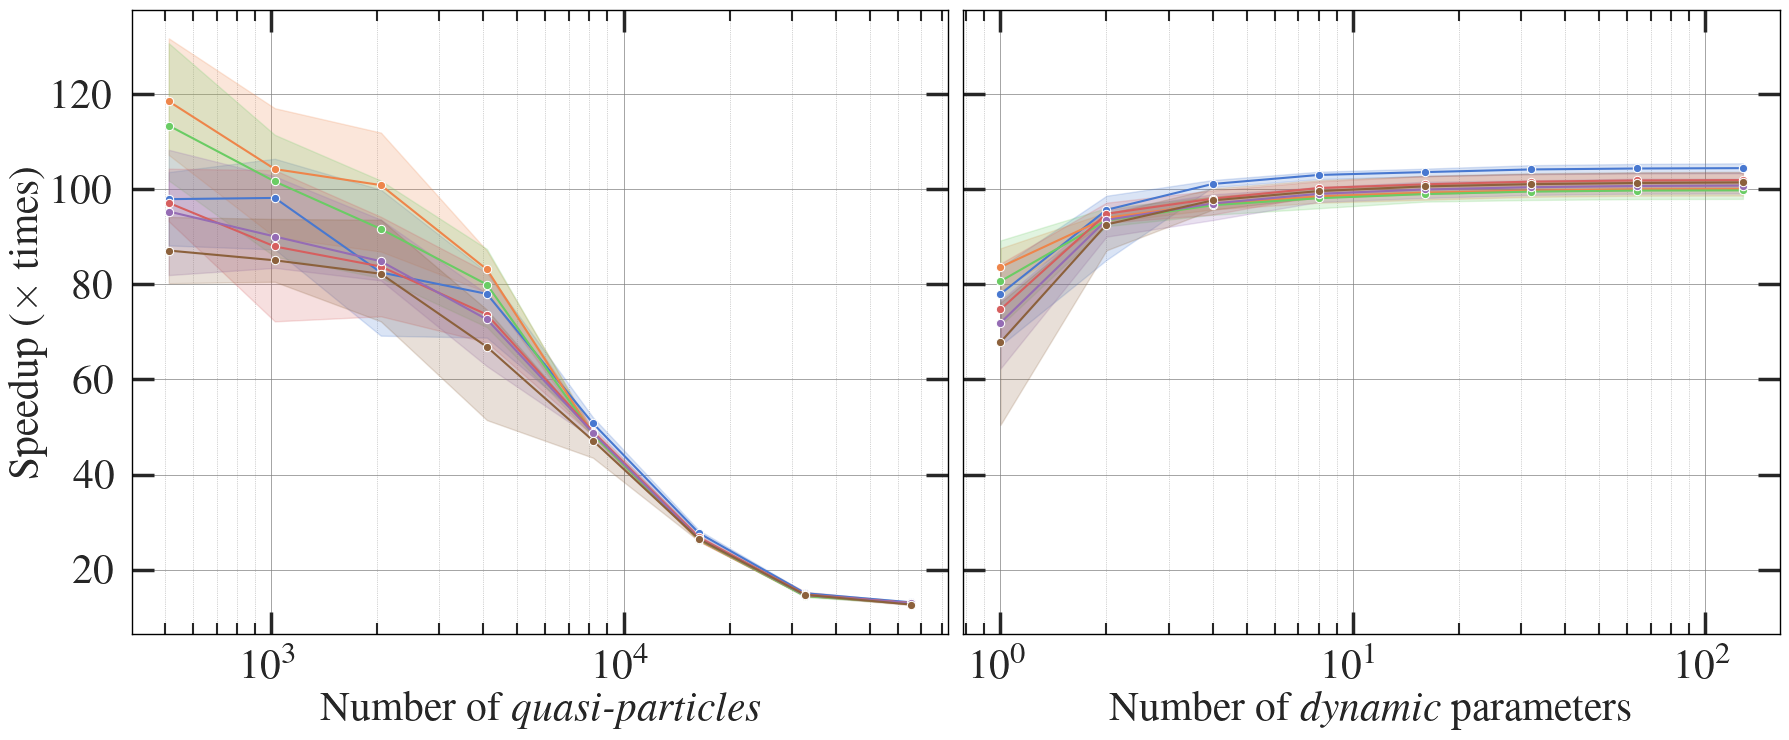

In [12]:
plot_scale_vs_speedup_per_date("A100", ("V0", "V8"))
save_plot('scale_vs_speedup_per_date')
plt.show()

In [13]:
def plot_scale_vs_time_per_date(device, version):
    df_ = df.query(f'(device == "{device}") & (version == "{version}")')
    fig, ax1, ax2 = make_pair_panel(sharey=True)

    sns.lineplot(
        data=df_.query('test == "part"'),
        x='val',
        y='exetime',
        hue='date',
        marker='o',
        errorbar=('pi', 95),
        palette='muted',
        ax=ax1,
    )
    ax1.set(xlabel=r'Number of \textit{quasi-particles}', ylabel='Runtime (min)')

    sns.lineplot(
        data=df_.query('test == "k0"'),
        x='val',
        y='exetime',
        hue='date',
        marker='o',
        errorbar=('pi', 95),
        palette='muted',
        ax=ax2,
    )
    ax2.set(xlabel=r'Number of \textit{dynamic} parameters', ylabel='Runtime (min)')

    make_figure_legend(fig, (ax1, ax2), "Carrington Rotation", map_labels=format_int_to_cr)

    return fig, ax1, ax2

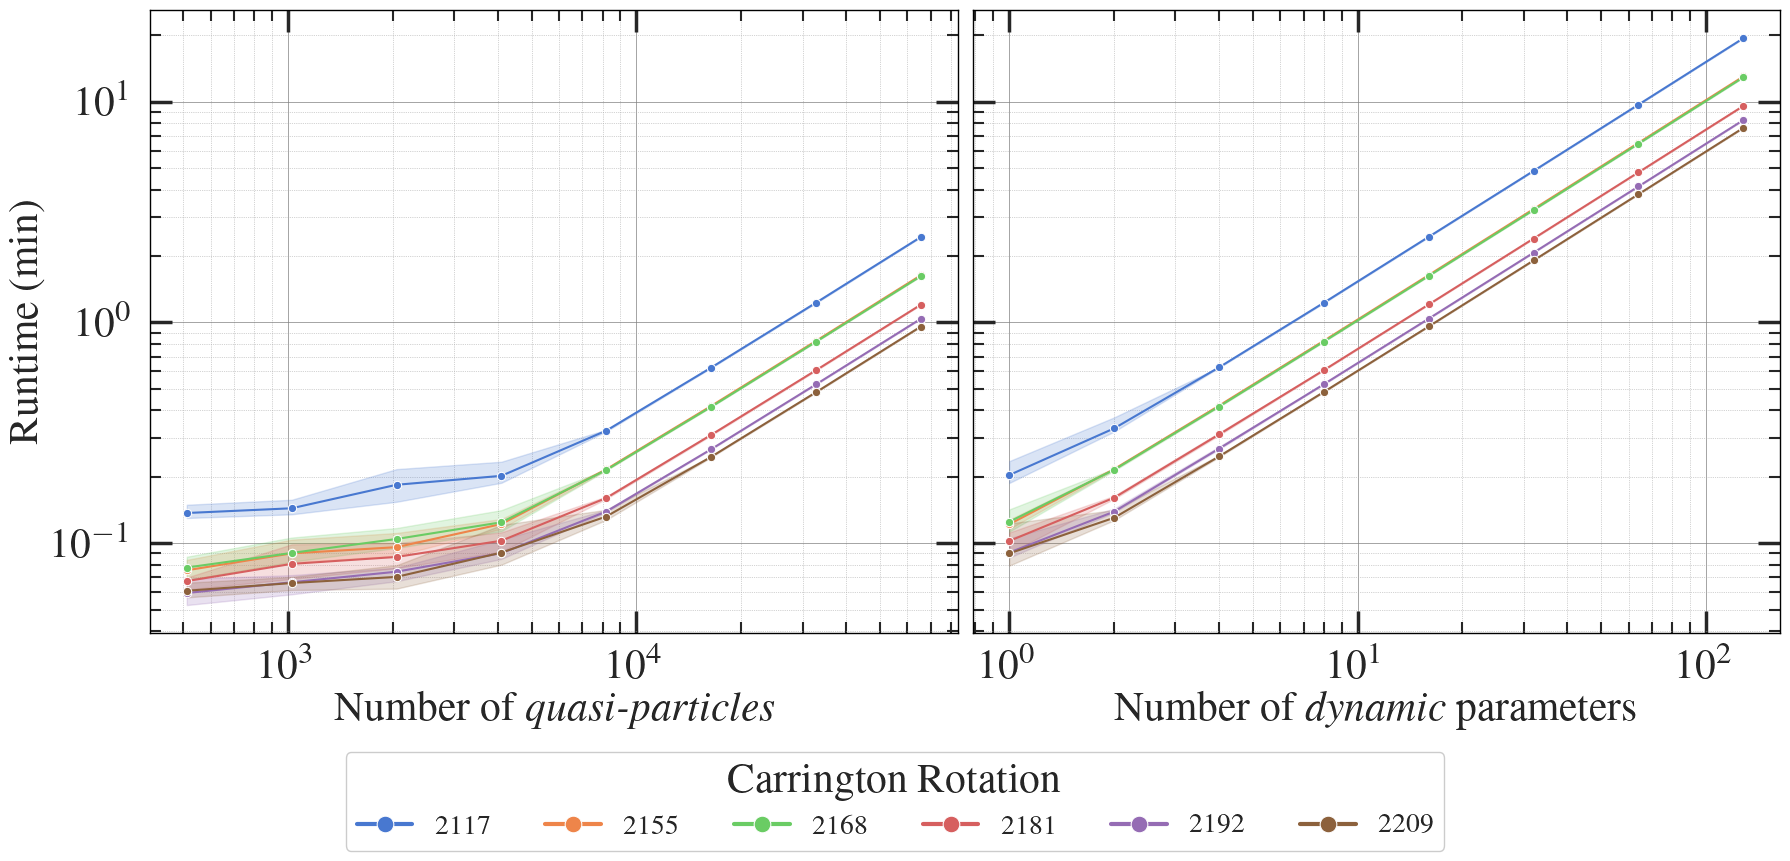

In [14]:
plot_scale_vs_time_per_date("A100", "V8")
save_plot('scale_vs_time_per_date')
plt.show()

In [15]:
def plot_scale_vs_speedup_per_device(devices, versions):
    df_ = pd.merge(
        df.query(f'(device.str.startswith("{devices[0]}")) & (version == "{versions[0]}")'),
        df.query(f'(device.str.startswith("{devices[0]}")) & (version == "{versions[1]}")'),
        on=['date', 'seed', 'test', 'val', 'device'],
    )
    df_['ratio'] = df_['exetime_x'] / df_['exetime_y']
    fig, ax1, ax2 = make_pair_panel(sharey=True)

    sns.lineplot(
        data=df_.query('test == "part"'),
        x='val',
        y='ratio',
        hue='device',
        marker='o',
        errorbar=('pi', 95),
        palette='muted',
        ax=ax1,
    )
    ax1.set(yscale='linear', xlabel=r'Number of \textit{quasi-particles}', ylabel=r'Speedup ($\times$ times)')

    sns.lineplot(
        data=df_.query('test == "k0"'),
        x='val',
        y='ratio',
        hue='device',
        marker='o',
        errorbar=('pi', 95),
        palette='muted',
        ax=ax2,
    )
    ax2.set(yscale='linear', xlabel=r'Number of \textit{dynamic} parameters', ylabel=r'Speedup ($\times$ times)')

    make_figure_legend(fig, (ax1, ax2), 'Configuration', map_labels=lambda x: x + ' (1x)' if x == 'A100' else x)

    return fig, ax1, ax2

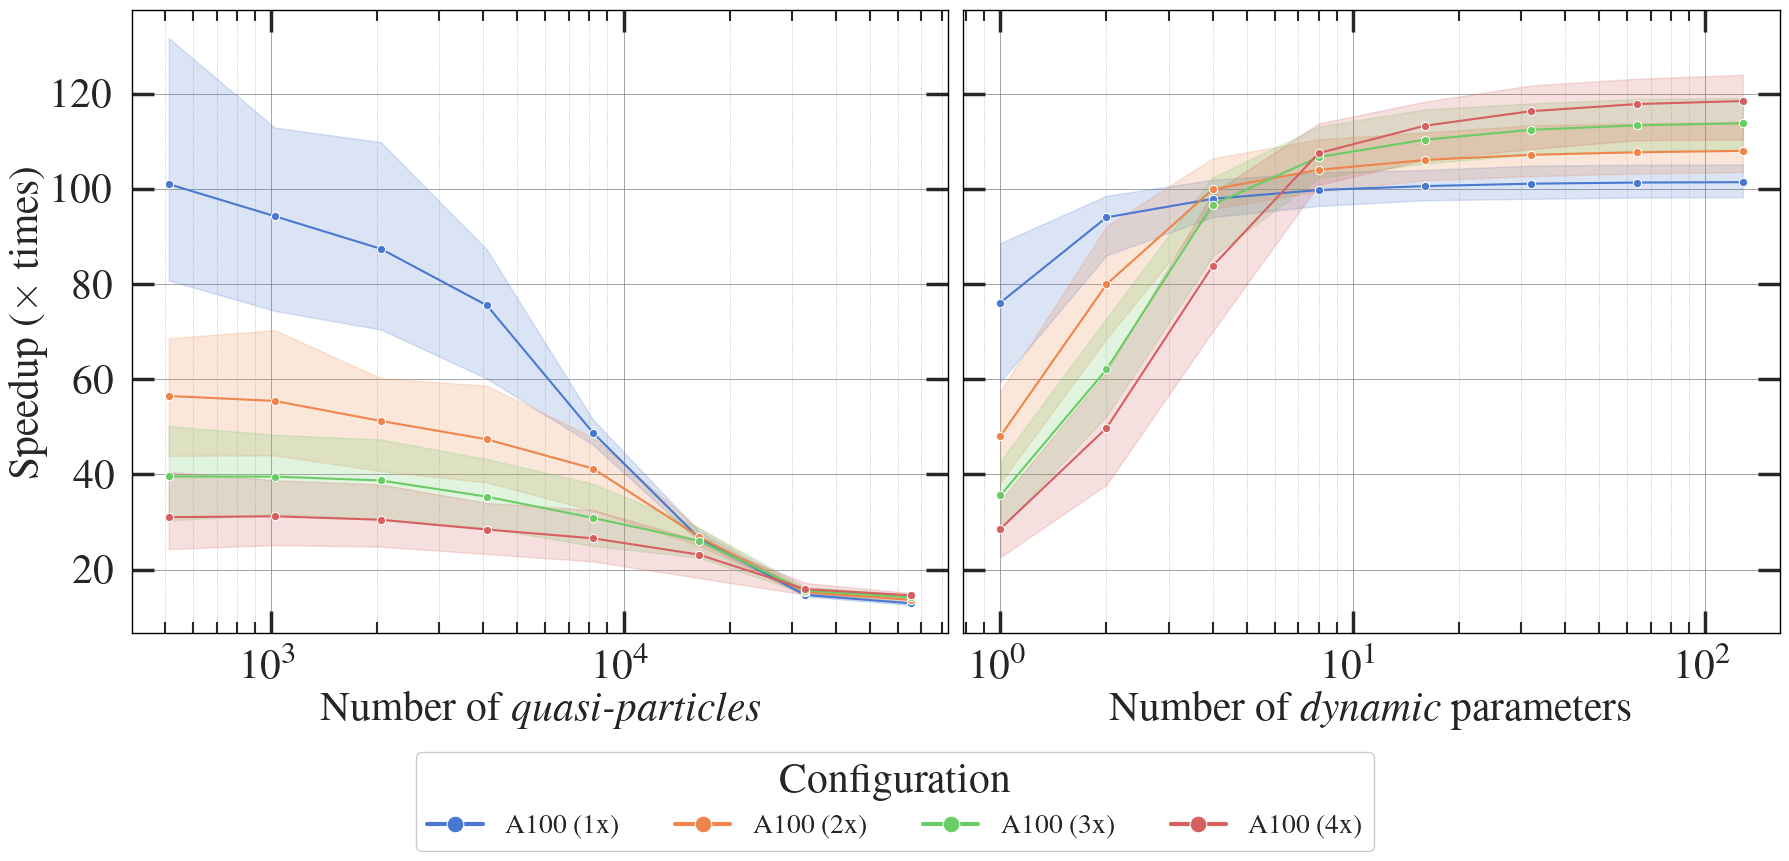

In [16]:
plot_scale_vs_speedup_per_device(('A100', 'A100 (2x)', 'A100 (3x)', 'A100 (4x)'), ("V0", "V8"))
save_plot('scale_vs_speedup_per_device')
plt.show()

In [17]:
def plot_scale_vs_speedup_per_device_date(date, devices, versions):
    df_ = pd.merge(
        df.query(f'(date == {date}) & (device.str.startswith("{devices[0]}")) & (version == "{versions[0]}")'),
        df.query(f'(date == {date}) & (device.str.startswith("{devices[0]}")) & (version == "{versions[1]}")'),
        on=['date', 'seed', 'test', 'val', 'device'],
    )
    df_['ratio'] = df_['exetime_x'] / df_['exetime_y']
    fig, ax1, ax2 = make_pair_panel(sharey=True)

    sns.lineplot(
        data=df_.query('test == "part"'),
        x='val',
        y='ratio',
        hue='device',
        marker='o',
        errorbar=('pi', 95),
        palette='muted',
        ax=ax1,
    )
    ax1.set(yscale='linear', xlabel=r'Number of \textit{quasi-particles}', ylabel=r'Speedup ($\times$ times)')

    sns.lineplot(
        data=df_.query('test == "k0"'),
        x='val',
        y='ratio',
        hue='device',
        marker='o',
        errorbar=('pi', 95),
        palette='muted',
        ax=ax2,
    )
    ax2.set(yscale='linear', xlabel=r'Number of \textit{dynamic} parameters', ylabel=r'Speedup ($\times$ times)')

    make_figure_legend(fig, (ax1, ax2), 'Configuration', map_labels=lambda x: x + ' (1x)' if x == 'A100' else x)

    return fig, ax1, ax2

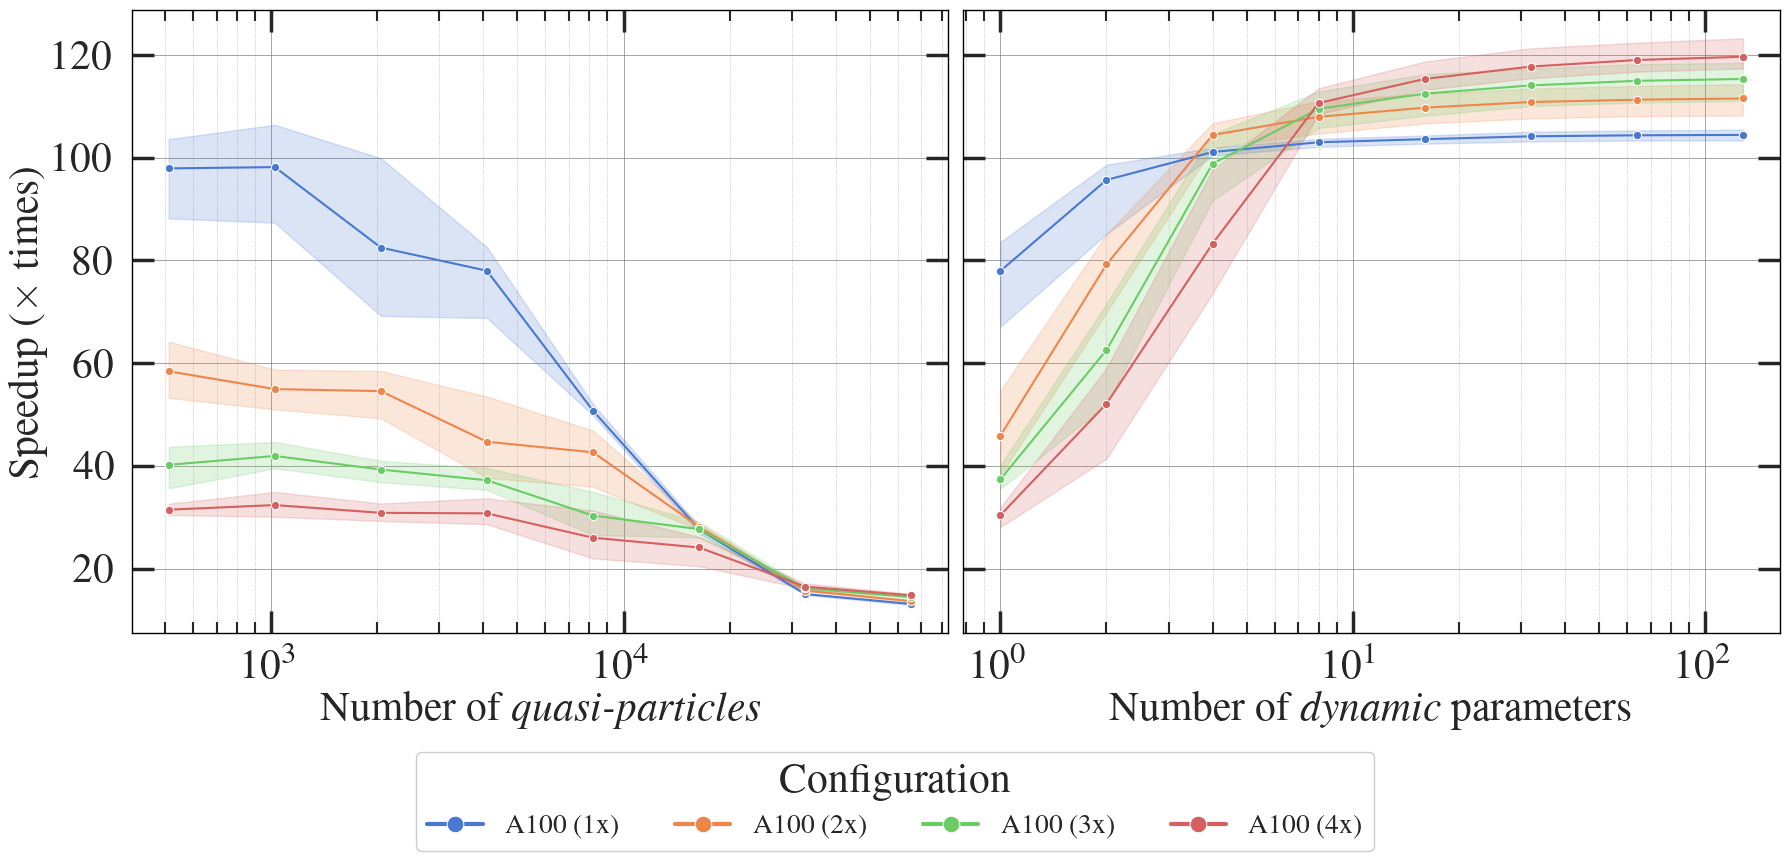

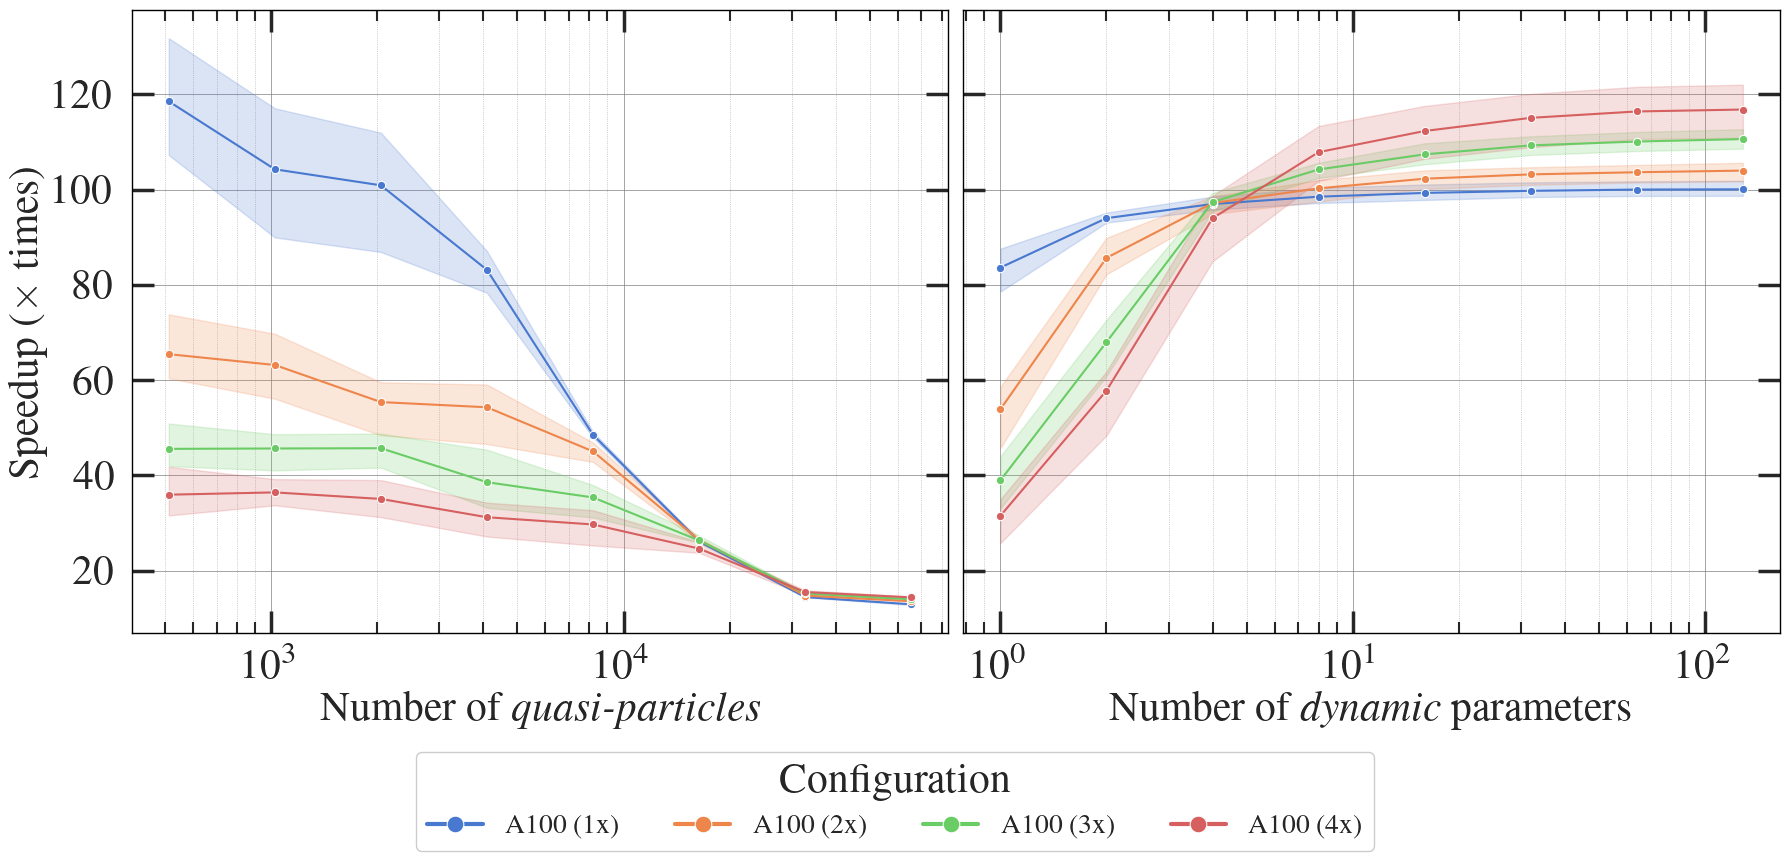

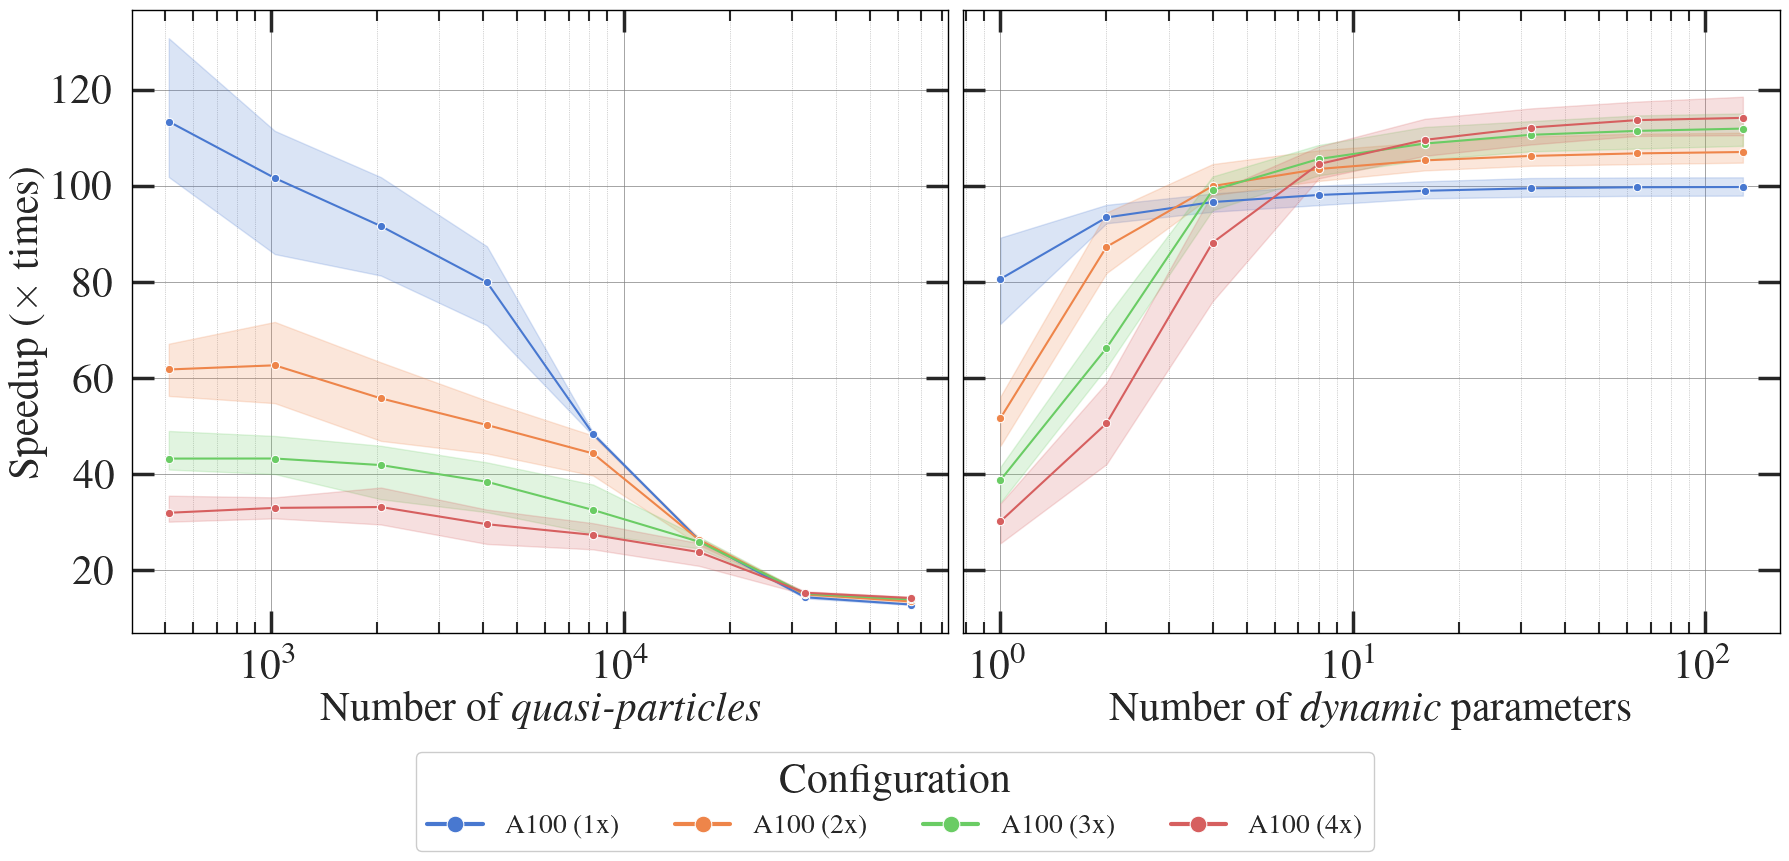

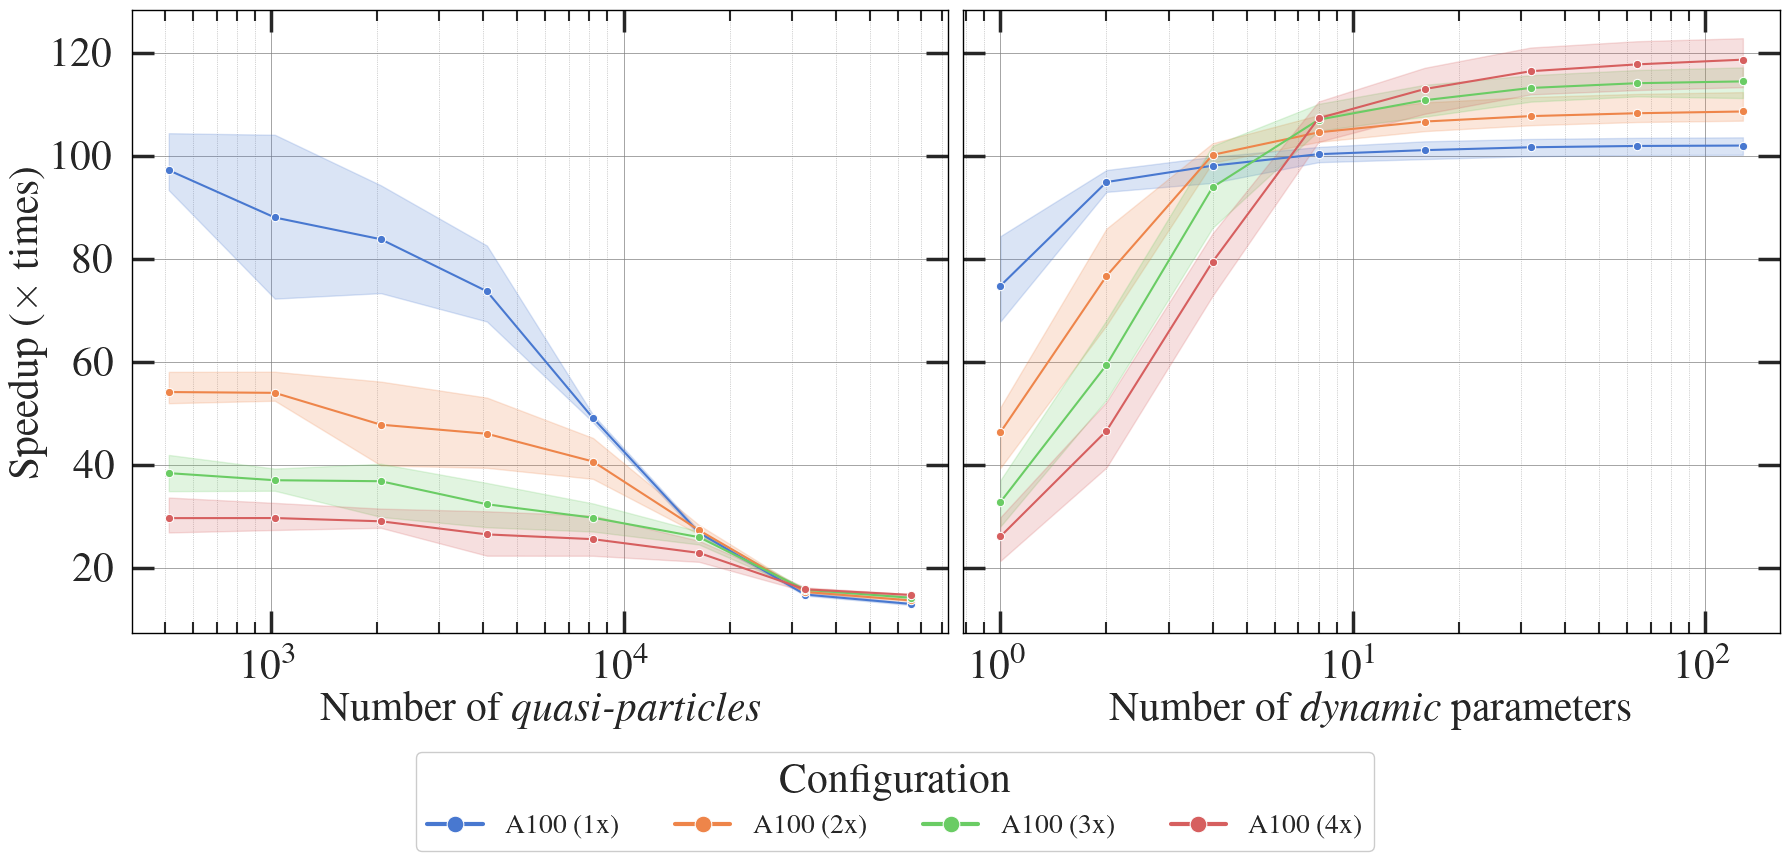

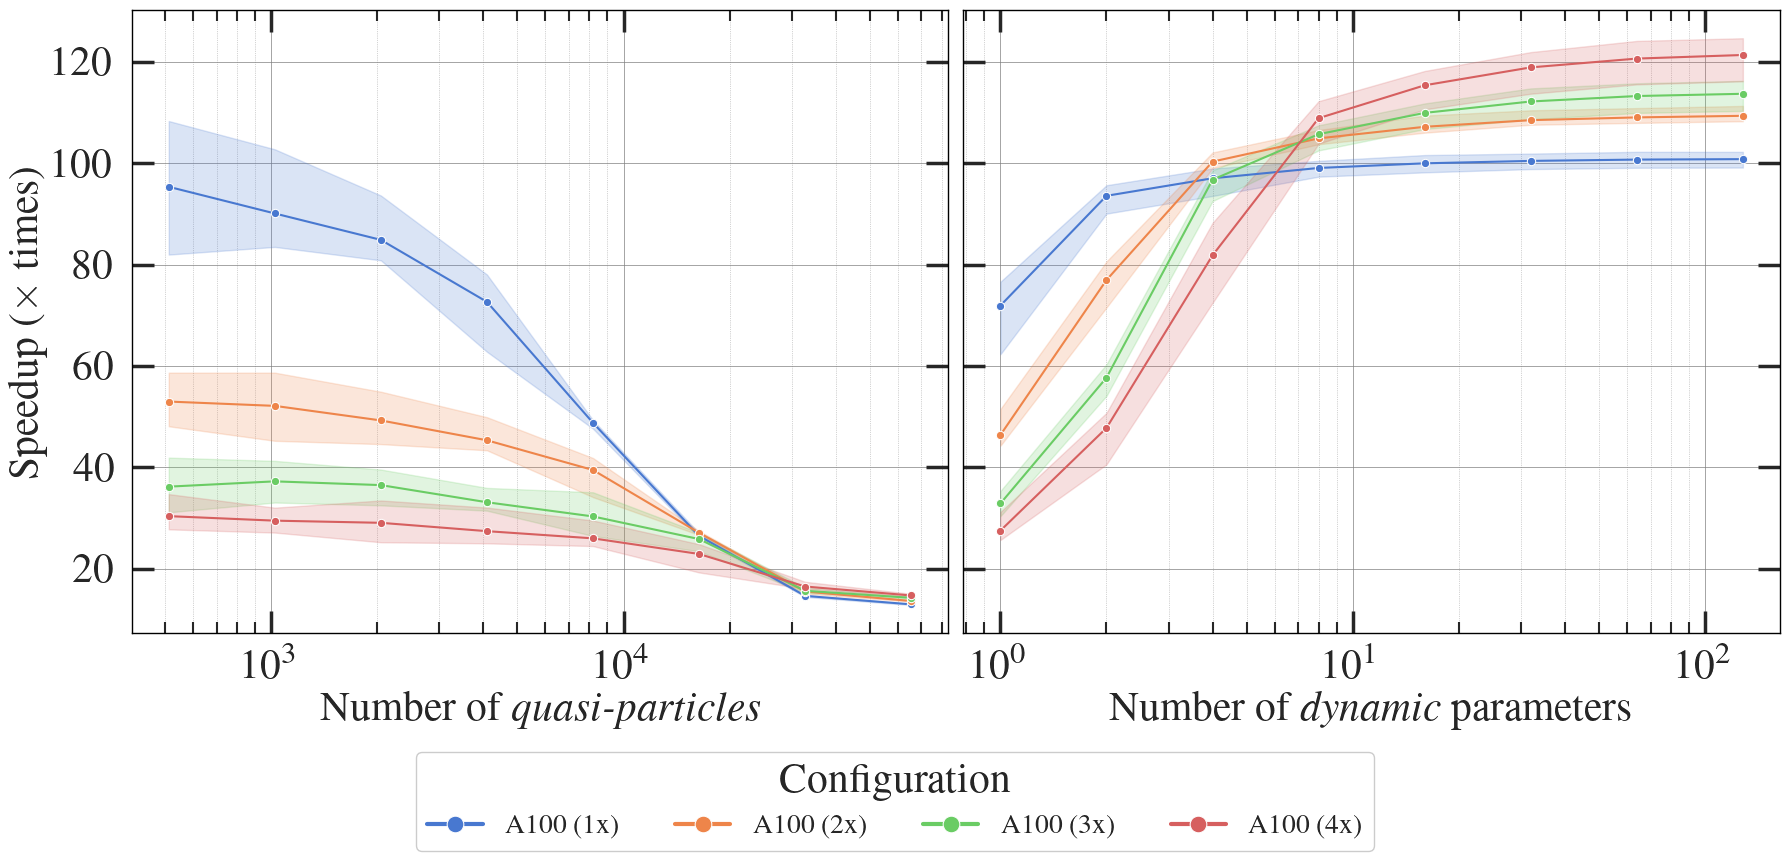

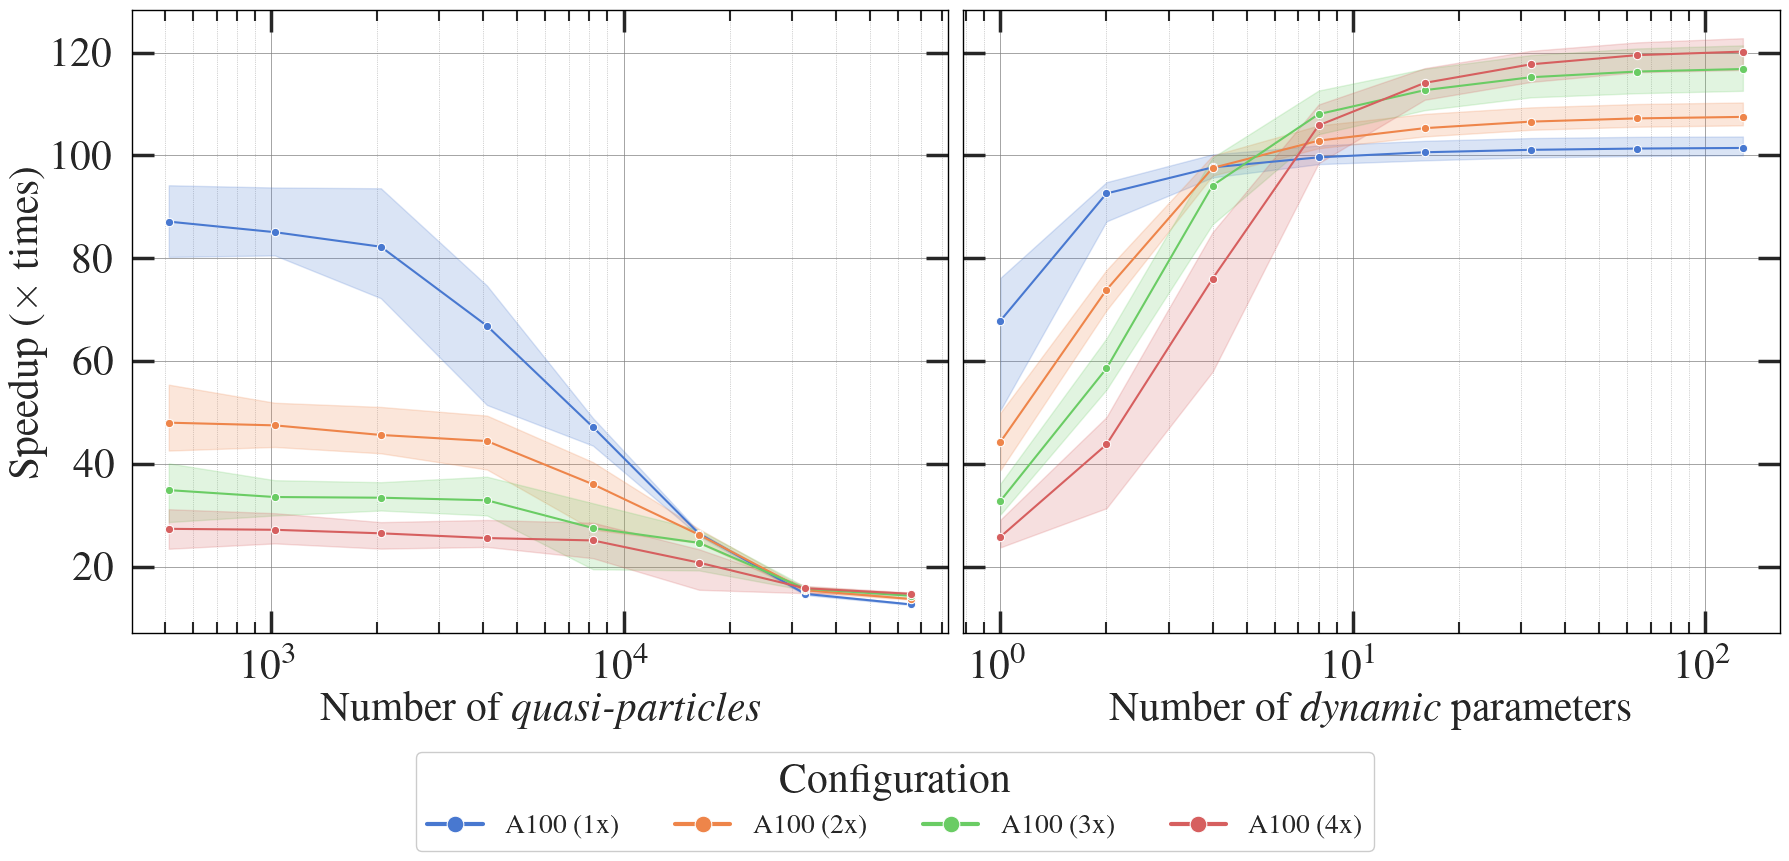

In [18]:
for date in df['date'].unique():
    plot_scale_vs_speedup_per_device_date(date, ('A100', 'A100 (2x)', 'A100 (3x)', 'A100 (4x)'), ("V0", "V8"))
    save_plot(f'scale_vs_speedup_per_device_{date}')
    plt.show()

In [19]:
def plot_scale_vs_energy_per_version(device):
    df_ = df.query(f'(device == "{device}")')
    fig, ax1, ax2 = make_pair_panel()

    sns.lineplot(
        data=df_.query('test == "part"'),
        x='val',
        y='power_energy',
        hue='version',
        marker='o',
        errorbar=('pi', 95),
        ax=ax1,
    )
    ax1.set(xlabel=r'Number of \textit{quasi-particles}', ylabel='Energy (Wh)')

    sns.lineplot(
        data=df_.query('test == "k0"'),
        x='val',
        y='power_energy',
        hue='version',
        marker='o',
        errorbar=('pi', 95),
        ax=ax2,
    )
    ax2.set(xlabel=r'Number of \textit{dynamic} parameters', ylabel='Energy (Wh)')

    make_figure_legend(fig, (ax1, ax2), 'Version',
                       map_labels=lambda x: 'HelMod-4/CUDA' if x == 'V0' else 'COSMICA (this work)')

    return fig, ax1, ax2

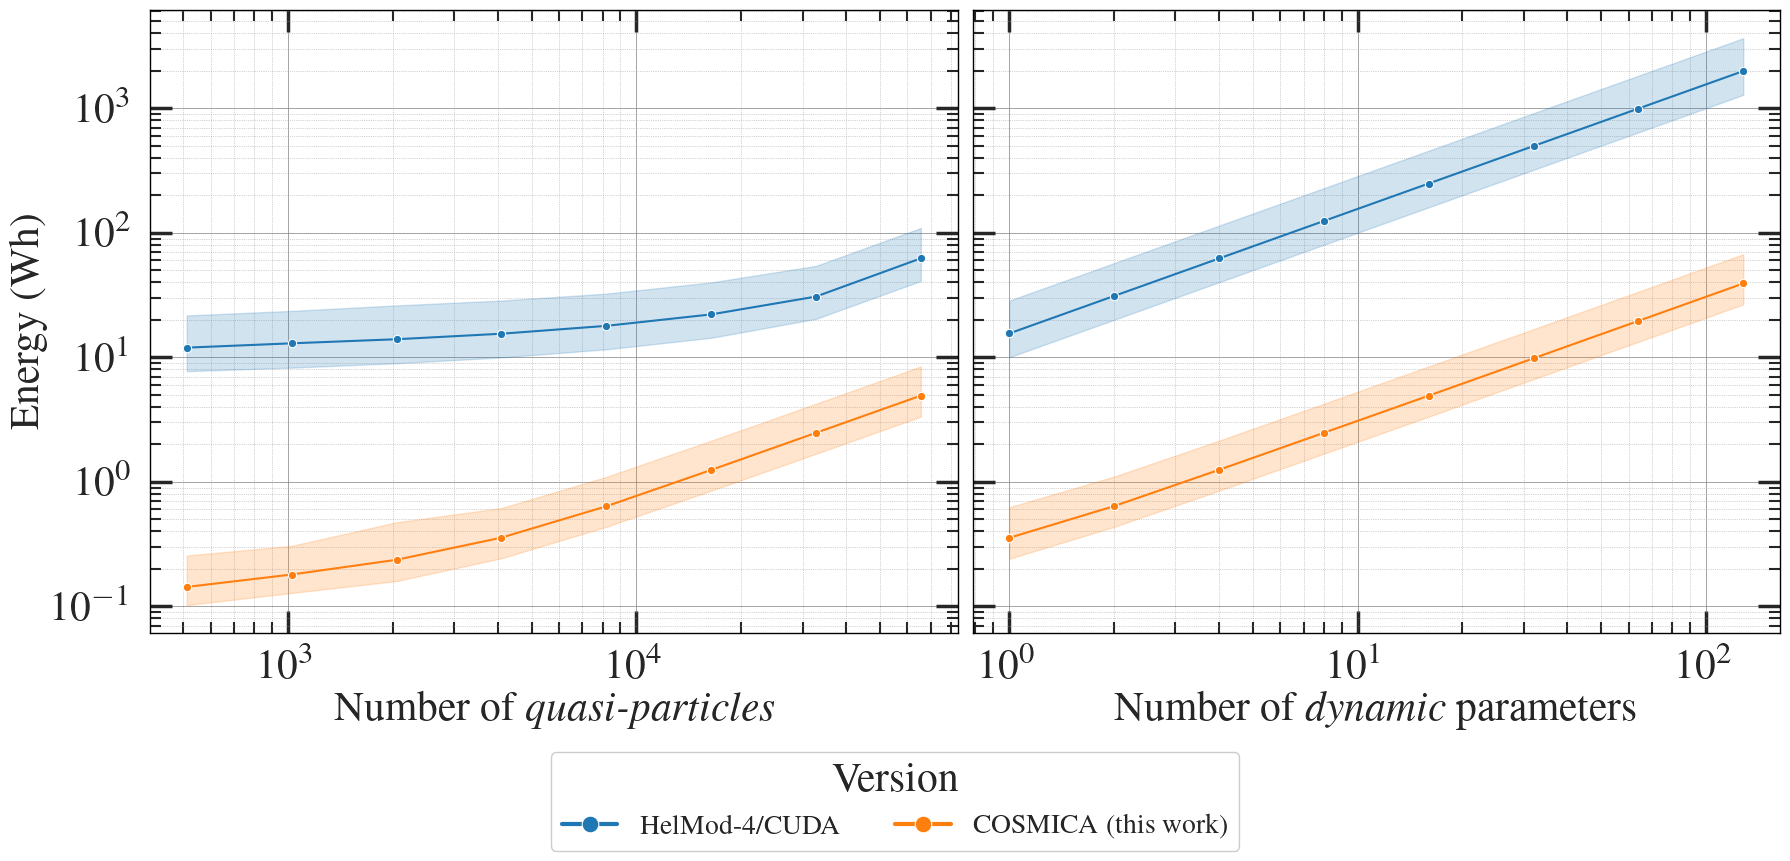

In [20]:
plot_scale_vs_energy_per_version("A100")
save_plot('scale_vs_energy_per_version')
plt.show()

In [21]:
def plot_scale_vs_power_per_version(device):
    df_ = df.query(f'(device == "{device}")')
    fig, ax1, ax2 = make_pair_panel()

    sns.lineplot(
        data=df_.query('test == "part"'),
        x='val',
        y='power_inst',
        hue='version',
        marker='o',
        errorbar=('pi', 95),
        ax=ax1,
    )
    ax1.set(xlabel=r'Number of \textit{quasi-particles}', ylabel='Power (W)')

    sns.lineplot(
        data=df_.query('test == "k0"'),
        x='val',
        y='power_inst',
        hue='version',
        marker='o',
        errorbar=('pi', 95),
        ax=ax2,
    )
    ax2.set(xlabel=r'Number of \textit{dynamic} parameters', ylabel='Power (W)')

    make_figure_legend(fig, (ax1, ax2), 'Version',
                       map_labels=lambda x: 'HelMod-4/CUDA' if x == 'V0' else 'COSMICA (this work)')

    return fig, ax1, ax2

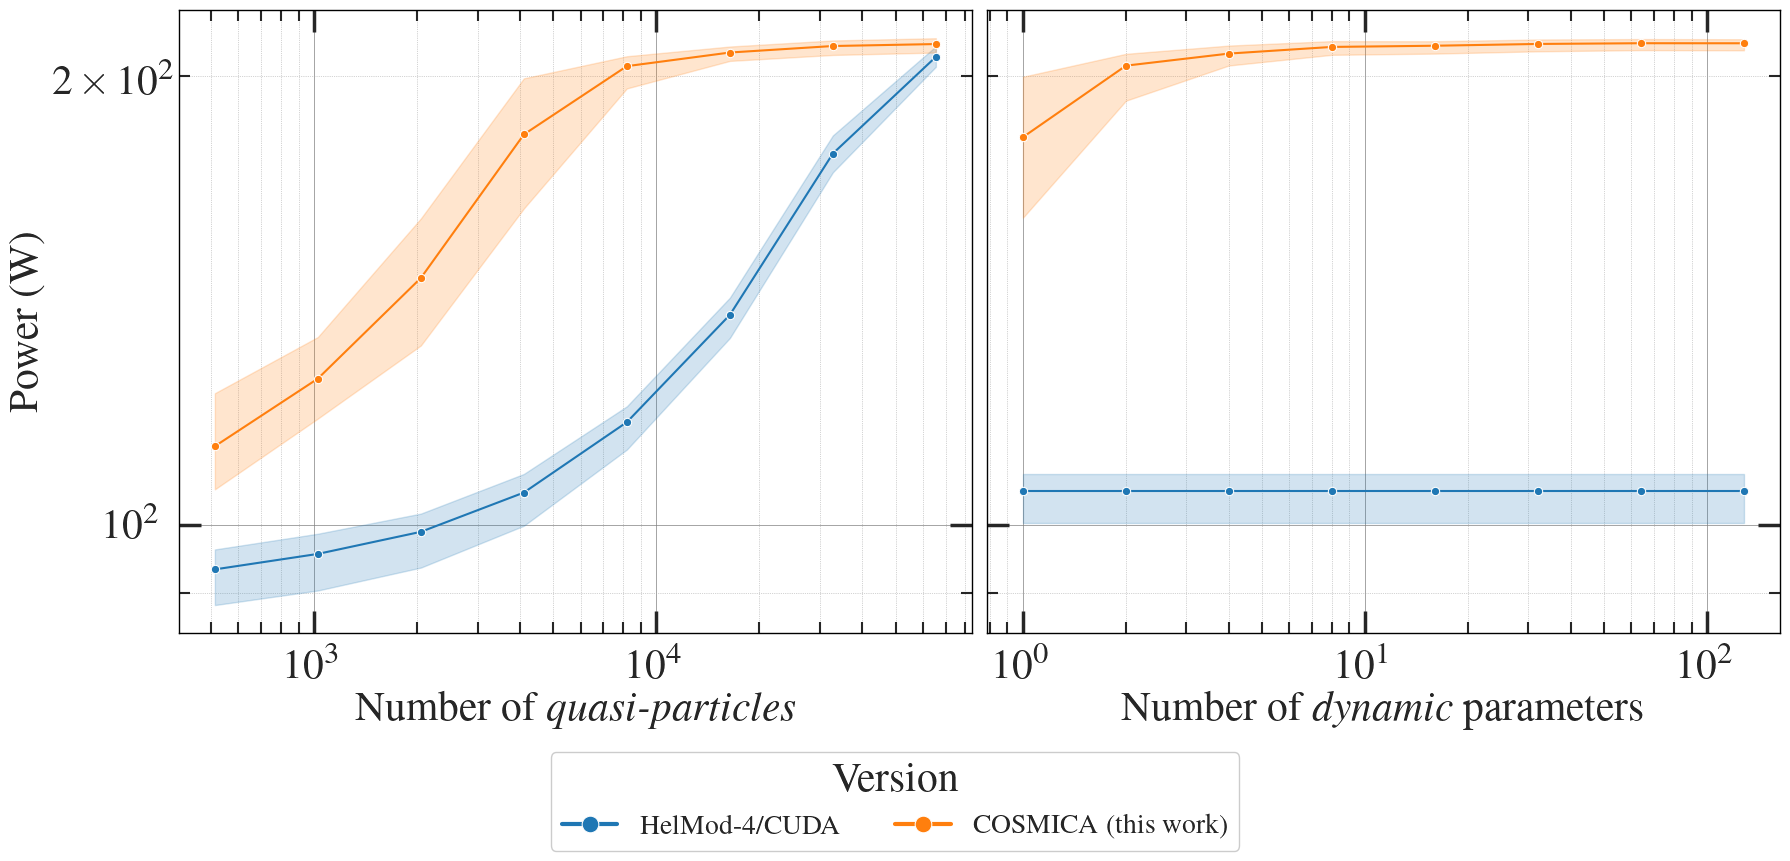

In [22]:
plot_scale_vs_power_per_version("A100")
save_plot('scale_vs_power_per_version')
plt.show()

In [23]:
def plot_device_vs_energy_per_date():
    fig, ax = plt.subplots(figsize=(18, 7.5), tight_layout=True)
    set_axis_fine_grid(ax, 'y')

    sns.barplot(
        data=df.query('(version == "V8") & (test == "k0") & (val == 128)'),
        x='device',
        y='power_energy',
        hue='date',
        errorbar=('pi', 95),
        capsize=.5,
        err_kws={'linewidth': 2},
        palette='muted',
        ax=ax,
    )
    ax.set(xlabel='GPU', ylabel='Energy (Wh)')
    ax.xaxis.set_ticks_position('none')

    make_figure_legend(fig, (ax,), 'Carrington Rotation', map_labels=format_int_to_cr)

    return fig, ax

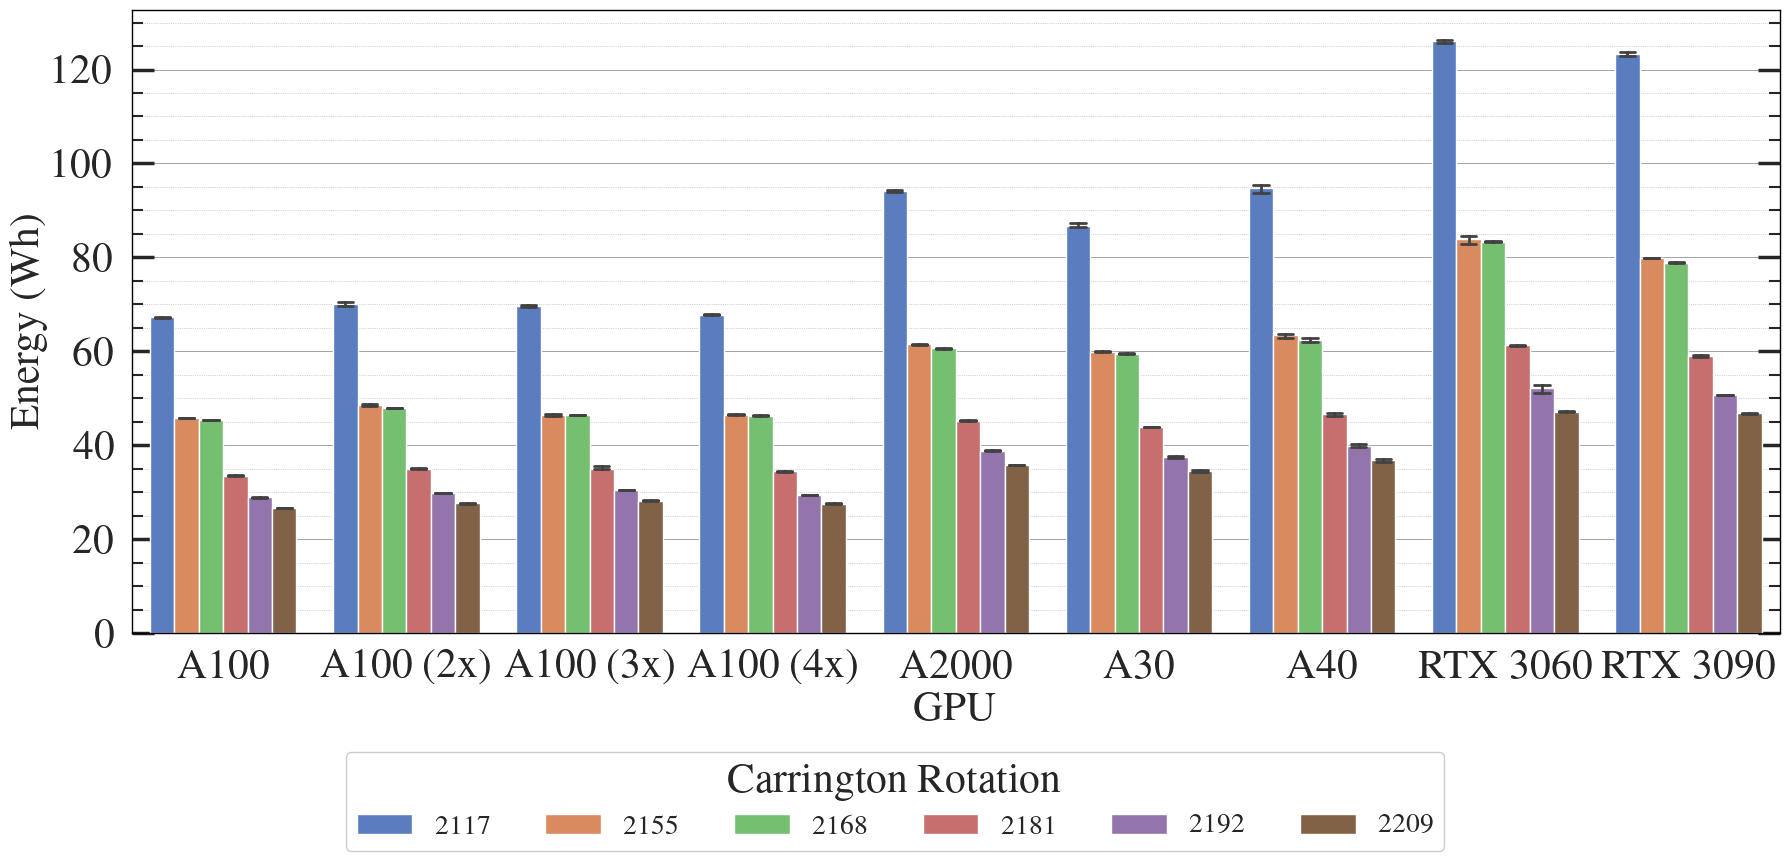

In [24]:
plot_device_vs_energy_per_date()
save_plot('device_vs_energy_per_date')
plt.show()

In [25]:
def plot_device_vs_power_per_param():
    fig, ax = plt.subplots(figsize=(18, 7.5), tight_layout=True)
    set_axis_fine_grid(ax, 'y')
    sns.barplot(
        data=df.query('(version == "V8") & (test == "k0")'),
        x='device',
        y='power_inst',
        hue='val',
        errorbar=('pi', 95),
        capsize=.5,
        err_kws={'linewidth': 2},
        palette='muted',
        ax=ax,
    )
    ax.set(xlabel='GPU', ylabel='Power (W)')
    ax.xaxis.set_ticks_position('none')

    make_figure_legend(fig, (ax,), r'Number of \textit{dynamic} parameters')

    return fig, ax

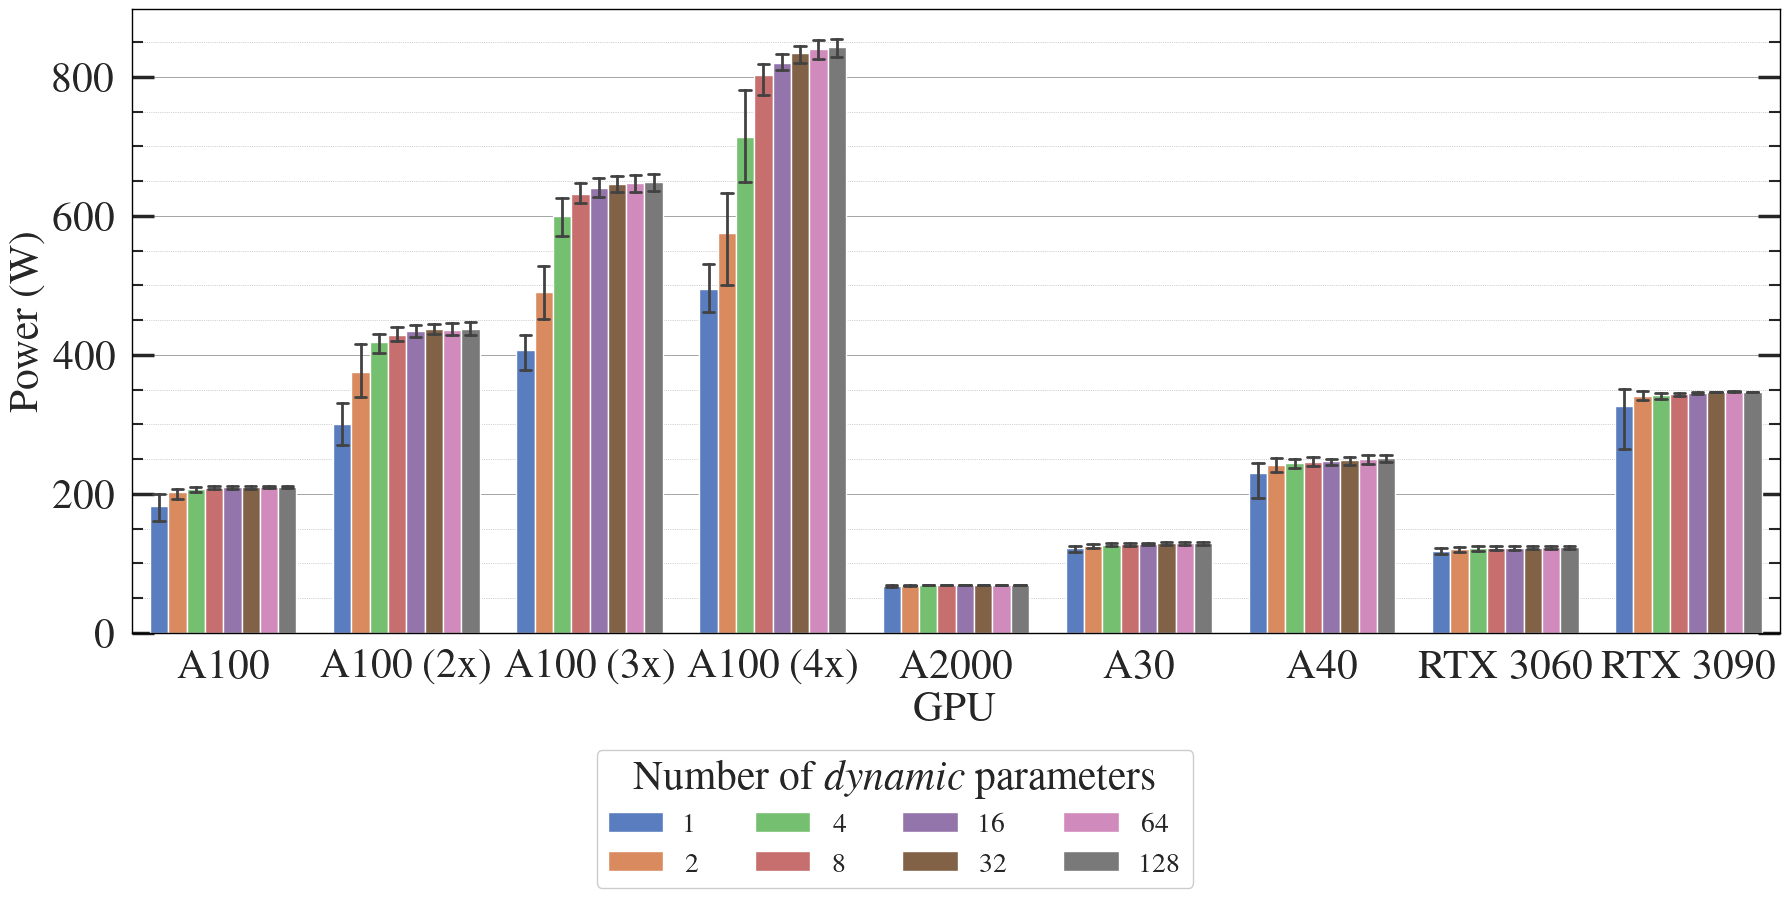

In [26]:
plot_device_vs_power_per_param()
save_plot('device_vs_power_per_param')
plt.show()

In [27]:
def plot_device_vs_power_per_part():
    fig, ax = plt.subplots(figsize=(18, 7.5), tight_layout=True)
    set_axis_fine_grid(ax, 'y')
    sns.barplot(
        data=df.query('(version == "V8") & (test == "part")'),
        x='device',
        y='power_inst',
        hue='val',
        errorbar=('pi', 95),
        capsize=.5,
        err_kws={'linewidth': 2},
        palette='muted',
        ax=ax,
    )
    ax.set(xlabel='GPU', ylabel='power (W)')
    ax.xaxis.set_ticks_position('none')

    make_figure_legend(fig, (ax,), r'Number particles')

    return fig, ax

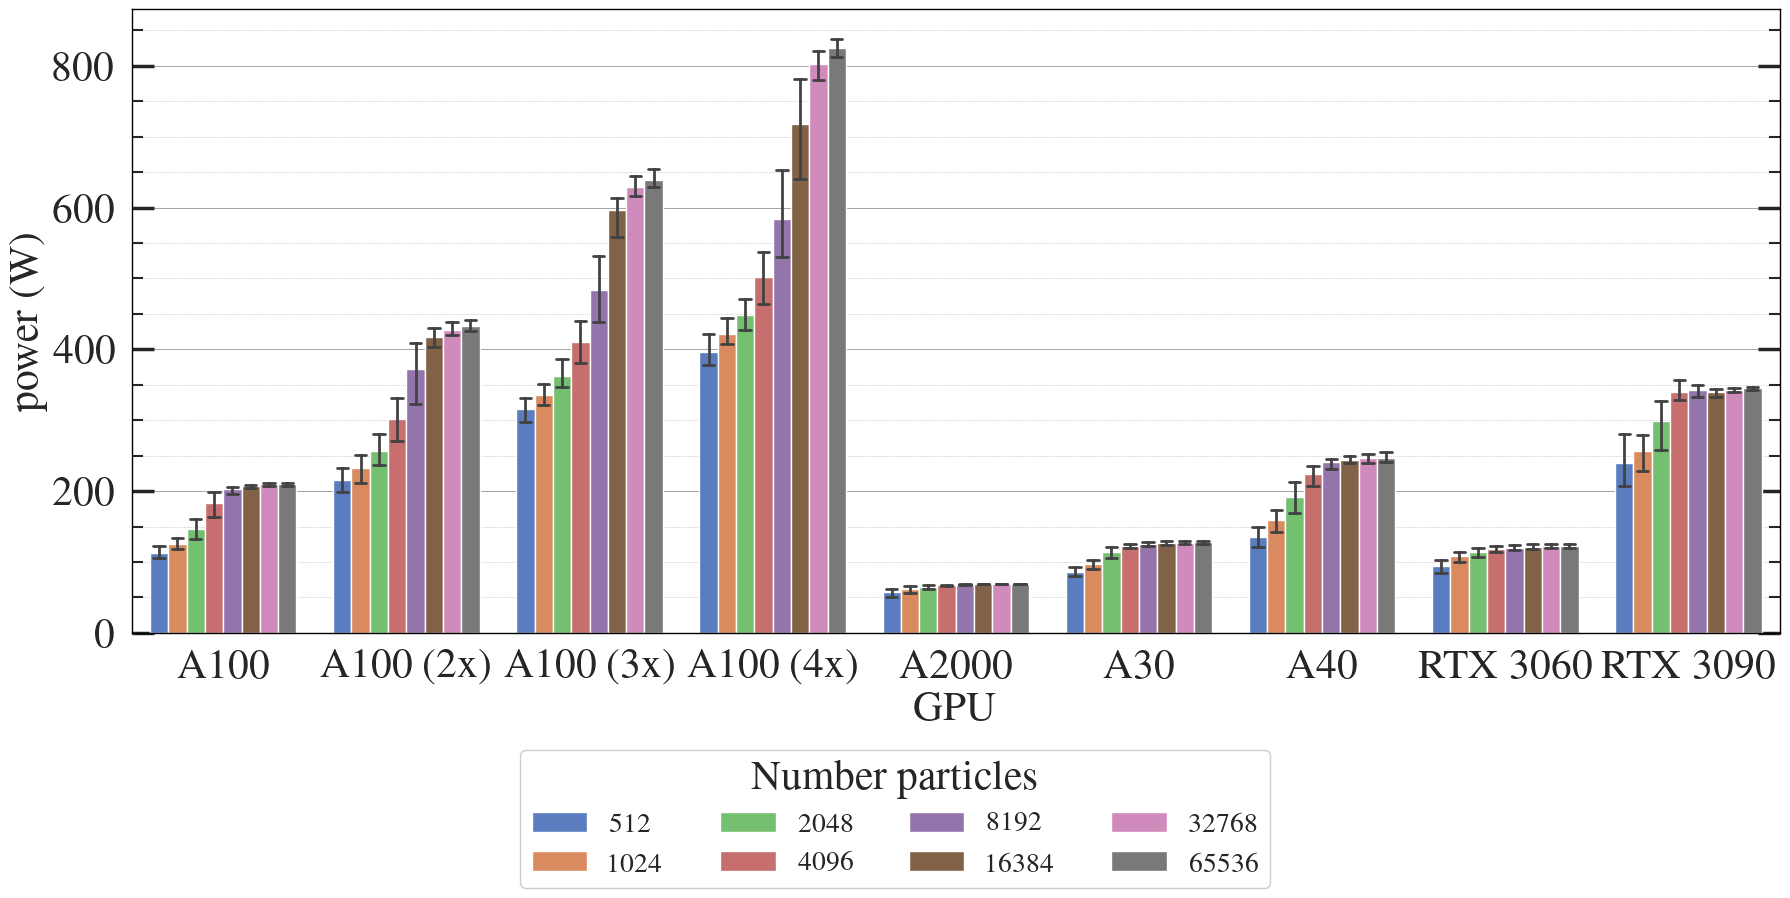

In [28]:
plot_device_vs_power_per_part()
save_plot('device_vs_power_per_part')
plt.show()

In [29]:
C = 0.86
G1 = 1499
W1 = df.query('(device == "RTX 3090") & (version == "V8")')['power_inst'].mean().item()
T1 = df.query('(device == "RTX 3090") & (version == "V8")')['exetime'].mean().item()
G2 = 15000
W2 = df.query('(device == "A100") & (version == "V8")')['power_inst'].mean().item()
T2 = df.query('(device == "A100") & (version == "V8")')['exetime'].mean().item()

(C * (G2 - G1) / (0.3 * (T1 * W1 - T2 * W2) / T2 / 1000))

241991.8278997719

In [30]:
C = 0.86
G1 = 1499
W1 = df.query('(device == "RTX 3090") & (version == "V8")')['power_inst'].mean().item()
T1 = df.query('(device == "RTX 3090") & (version == "V8")')['exetime'].mean().item()
G2 = 8000
W2 = df.query('(device == "A40") & (version == "V8")')['power_inst'].mean().item()
T2 = df.query('(device == "A40") & (version == "V8")')['exetime'].mean().item()

(C * (G2 - G1) / (0.3 * (T1 * W1 - T2 * W2) / T2 / 1000))

251845.7990096807